In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import nc_time_axis 
import cftime


In [108]:
import matplotlib.pyplot as plt
def grafico_linea_ts(xmin,xmax,xlab,ylab,title,ymin=None,ymax=None,legend=False):
    # especificar limites minimos y maximos del grafico
    plt.xlim([xmin,xmax])
    plt.ylim([ymin,ymax])
    # cuadrilla interna del grafico
    plt.grid(linestyle='--',alpha=0.66)
    plt.minorticks_on()
    # hacer las etiquetas de ambos ejes mas grandes
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    # poner las labels de los ejes y el titulo
    plt.xlabel(xlab,fontsize=18)
    plt.ylabel(ylab,fontsize=18)
    plt.title(title,fontsize=18)
    # checar si queremos leyenda, si sí, la ponemos y fancy
    if legend:
        plt.legend(fontsize=11,fancybox=True,shadow=True)

In [3]:
## Carga del archivo de X 1 de CO2
pr1= xr.open_dataset('pr_1xCO2_run_cesm1-lens_1850-1999.nc')

In [4]:
# Se visualiza que los datos son globables, tenemos año, latitud y longitud
## Las variables que se pueden observar son de precipitacion, pr tiene promedio de precipitación anual, por lo que para las graficas anuales
## no es necesario promediar los datos
### De igual forma, tenemos promedios de precipitacion para diciembre enero y febrero (pr_djf)
###Promedio para junio, julio y agosto, precipitacion maxima para los mismos meses (diciembre-enero-febrero, junio-julio-agosto)
#### Y por ultimo promedio de temperatura superficial anual para los mismos periodos de tiempo
pr1

<xarray.Dataset> Size: 598MB
Dimensions:     (year: 150, lat: 192, lon: 288)
Coordinates:
  * year        (year) int64 1kB 1850 1851 1852 1853 ... 1996 1997 1998 1999
  * lat         (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon         (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
Data variables:
    pr          (year, lat, lon) float64 66MB ...
    pr_djf      (year, lat, lon) float64 66MB ...
    pr_jja      (year, lat, lon) float64 66MB ...
    pr_max      (year, lat, lon) float64 66MB ...
    pr_max_djf  (year, lat, lon) float64 66MB ...
    pr_max_jja  (year, lat, lon) float64 66MB ...
    tas         (year, lat, lon) float64 66MB ...
    tas_djf     (year, lat, lon) float64 66MB ...
    tas_jja     (year, lat, lon) float64 66MB ...
    weight      (lat, lon) float64 442kB ...

In [5]:
## Cambio de la variable del tiempo a un datetime64

pr1['year'] = [pd.Timestamp(str(t)) for t in pr1['year'].values]

In [6]:
pr1['pr']

<xarray.DataArray 'pr' (year: 150, lat: 192, lon: 288)> Size: 66MB
[8294400 values with dtype=float64]
Coordinates:
  * year     (year) datetime64[ns] 1kB 1850-01-01 1851-01-01 ... 1999-01-01
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Attributes:
    descr:    annual mean PRECC+PRECCL, convective + large scale precip.
    units:    mm/day
    run::     1xCO2 abrupt run
    model:    CESM1-LENS

In [7]:
pr1


<xarray.Dataset> Size: 598MB
Dimensions:     (year: 150, lat: 192, lon: 288)
Coordinates:
  * year        (year) datetime64[ns] 1kB 1850-01-01 1851-01-01 ... 1999-01-01
  * lat         (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon         (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
Data variables:
    pr          (year, lat, lon) float64 66MB ...
    pr_djf      (year, lat, lon) float64 66MB ...
    pr_jja      (year, lat, lon) float64 66MB ...
    pr_max      (year, lat, lon) float64 66MB ...
    pr_max_djf  (year, lat, lon) float64 66MB ...
    pr_max_jja  (year, lat, lon) float64 66MB ...
    tas         (year, lat, lon) float64 66MB ...
    tas_djf     (year, lat, lon) float64 66MB ...
    tas_jja     (year, lat, lon) float64 66MB ...
    weight      (lat, lon) float64 442kB ...

In [8]:
pr1.pr.max()

<xarray.DataArray 'pr' ()> Size: 8B
array(39.74730301)

In [9]:
##Cambio de float64 a float32 para una mejor lectura de los datos

pr1['pr'] = pr1['pr'].astype('float32')

In [10]:
year=pr1['year']

In [11]:
precip1=pr1.pr

In [12]:
### Cambio de longitud a un formato de -180 a 180
precip1 = precip1.assign_coords(lon=((precip1.lon + 180) % 360) - 180).sortby('lon')

# Delimitación del periodo de estudio
#precip1= precip1.where((year >= "1870-01-01") & (year <= "1999-01-01"), drop=True)
precip1=precip1.sel(year=slice("1969-01-01", "1999-12-31"))
precip1

<xarray.DataArray 'pr' (year: 31, lat: 192, lon: 288)> Size: 7MB
array([[[0.16844308, 0.16841596, 0.16841578, ..., 0.16841765,
         0.16841617, 0.16843073],
        [0.23952618, 0.24024275, 0.24048004, ..., 0.23377211,
         0.2360883 , 0.23809566],
        [0.19282635, 0.19833516, 0.20320107, ..., 0.1770341 ,
         0.18206757, 0.18758725],
        ...,
        [0.6078254 , 0.60876054, 0.6069974 , ..., 0.6094824 ,
         0.60938764, 0.60887897],
        [0.607554  , 0.60968506, 0.6096368 , ..., 0.60398823,
         0.6040398 , 0.604682  ],
        [0.60607547, 0.6062208 , 0.6062664 , ..., 0.60597366,
         0.6059668 , 0.6060166 ]],

       [[0.17341717, 0.17341806, 0.1734172 , ..., 0.17341919,
         0.17340788, 0.17341949],
        [0.238867  , 0.24019238, 0.24241592, ..., 0.23127909,
         0.23384282, 0.23615327],
        [0.1891265 , 0.1944036 , 0.19949953, ..., 0.17250119,
         0.17797488, 0.18389548],
...
        [0.4120195 , 0.4100423 , 0.40711623, ..., 0.41660815,
         0.4152744 , 0.41138497],
        [0.4263201 , 0.42635852, 0.42387962, ..., 0.4283516 ,
         0.4281296 , 0.42639834],
        [0.4069684 , 0.40696734, 0.4070014 , ..., 0.4069672 ,
         0.40697294, 0.4069765 ]],

       [[0.16363524, 0.16362095, 0.16362481, ..., 0.16361952,
         0.1636194 , 0.16363522],
        [0.2227488 , 0.22411464, 0.22482756, ..., 0.21703397,
         0.21943504, 0.22116858],
        [0.18689957, 0.1921069 , 0.19736409, ..., 0.1716808 ,
         0.176884  , 0.18197718],
        ...,
        [0.7647262 , 0.7642006 , 0.76781046, ..., 0.7609451 ,
         0.7606876 , 0.7633619 ],
        [0.7750906 , 0.77415895, 0.7774629 , ..., 0.768061  ,
         0.771793  , 0.7727935 ],
        [0.70286536, 0.70295036, 0.70287615, ..., 0.7029154 ,
         0.70294833, 0.7029582 ]]], shape=(31, 192, 288), dtype=float32)
Coordinates:
  * year     (year) datetime64[ns] 248B 1969-01-01 1970-01-01 ... 1999-01-01
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB -180.0 -178.8 -177.5 -176.2 ... 176.2 177.5 178.8
Attributes:
    descr:    annual mean PRECC+PRECCL, convective + large scale precip.
    units:    mm/day
    run::     1xCO2 abrupt run
    model:    CESM1-LENS

(array([1.34681e+06, 3.01192e+05, 5.85650e+04, 6.63400e+03, 5.35000e+02,
        2.27000e+02, 1.06000e+02, 8.20000e+01, 1.90000e+01, 6.00000e+00]),
 array([7.22821709e-03, 3.61629844e+00, 7.22536898e+00, 1.08344393e+01,
        1.44435091e+01, 1.80525799e+01, 2.16616516e+01, 2.52707214e+01,
        2.88797913e+01, 3.24888611e+01, 3.60979309e+01]),
 <BarContainer object of 10 artists>)

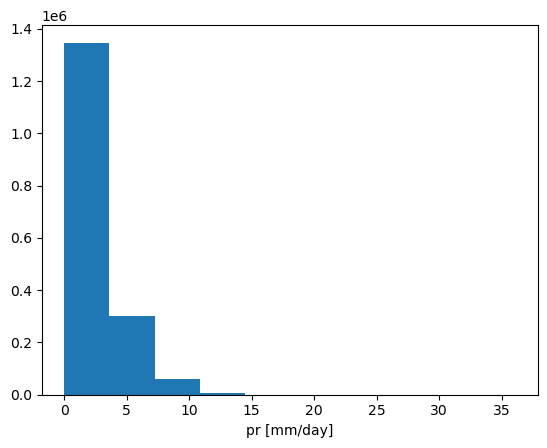

In [13]:
precip1.plot()

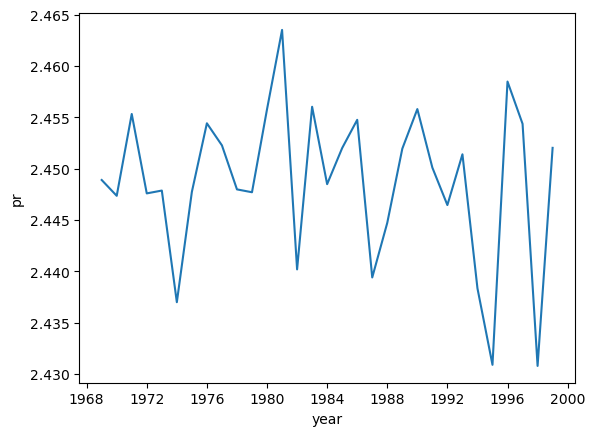

In [14]:
## Primer vistazo a la serie de tiempo anual global 

precip1.mean(('lat','lon')).plot()

In [15]:
## Delimitación del area de estudio para el promedio de precipitación anual
p1 = precip1.sel(lon=slice(-112, -102), lat=slice(18, 33))

In [16]:
pre1= p1.mean(('lat','lon'))

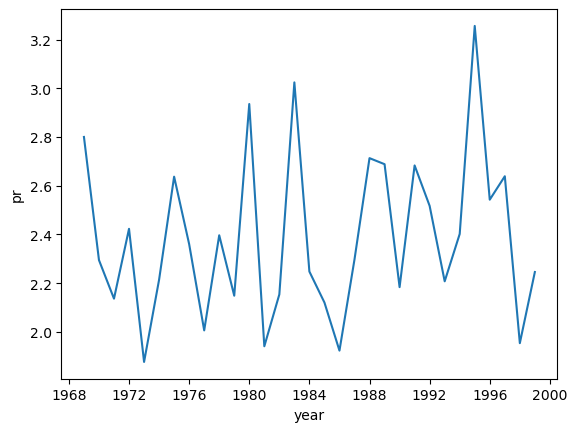

In [17]:
## Serie de tiempo anual de la region del NAM
pre1.plot()

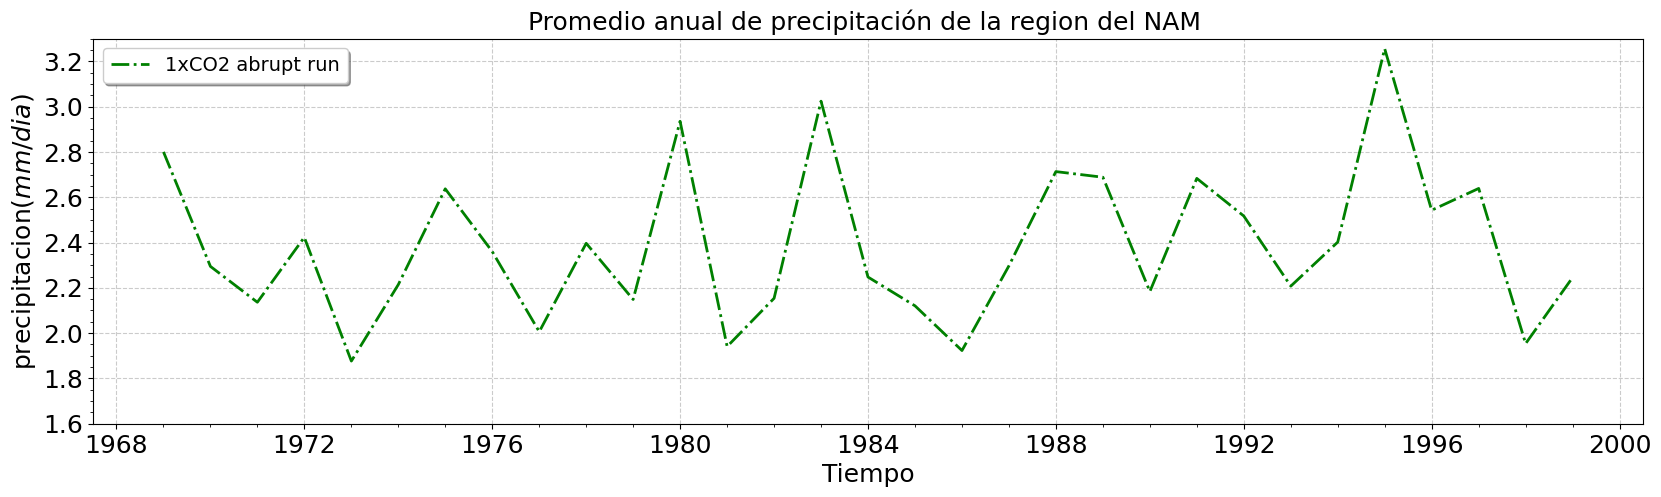

In [18]:
plt.figure(figsize=(20,5))
plt.plot(precip1.year,pre1,c='green',label='1xCO2 abrupt run',linewidth=2,linestyle='-.')
grafico_linea_ts(None,None,'Tiempo','precipitacion($mm /dia$)','Promedio anual de precipitación de la region del NAM ',ymin=1.6,ymax=3.3,legend=True)

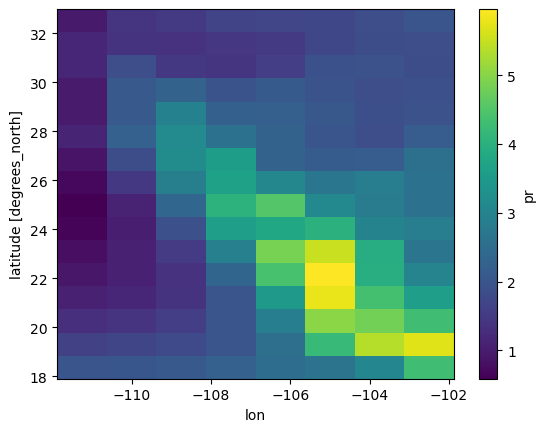

In [19]:
ANUAL=p1.mean(("year"), skipna= True)
ANUAL.plot()

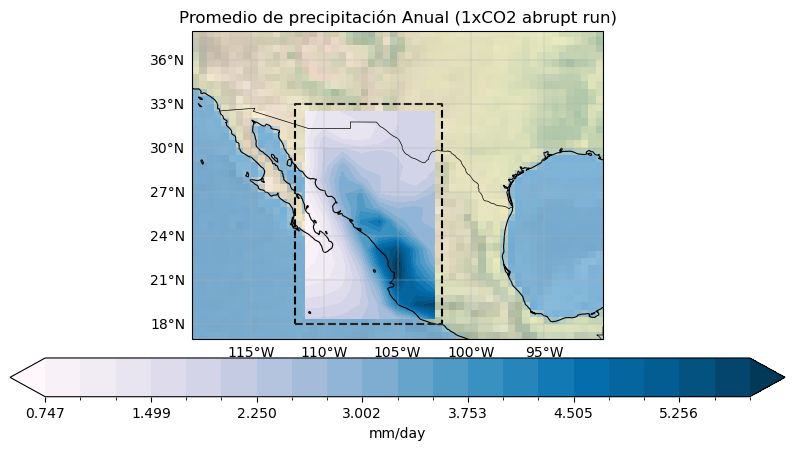

In [20]:
levels = np.linspace(float(ANUAL.quantile(0.02)), float(ANUAL.quantile(0.99)), 21)


fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)




cf = ANUAL.plot.contourf(ax=ax,transform=ccrs.PlateCarree(),
                      levels=levels, add_colorbar=False,cmap='PuBu', extend="both")
lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=p1.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación Anual (1xCO2 abrupt run)")
#plt.savefig('Datos filtrados/Promedio de precipitación Anual .png')
plt.show()

In [21]:
pr1['pr_jja'] = pr1['pr_jja'].astype('float32')

In [22]:
pr1

<xarray.Dataset> Size: 531MB
Dimensions:     (year: 150, lat: 192, lon: 288)
Coordinates:
  * year        (year) datetime64[ns] 1kB 1850-01-01 1851-01-01 ... 1999-01-01
  * lat         (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon         (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
Data variables:
    pr          (year, lat, lon) float32 33MB 0.1866 0.1866 ... 0.703 0.7031
    pr_djf      (year, lat, lon) float64 66MB ...
    pr_jja      (year, lat, lon) float32 33MB 0.1857 0.1858 ... 0.6299 0.6299
    pr_max      (year, lat, lon) float64 66MB ...
    pr_max_djf  (year, lat, lon) float64 66MB ...
    pr_max_jja  (year, lat, lon) float64 66MB ...
    tas         (year, lat, lon) float64 66MB ...
    tas_djf     (year, lat, lon) float64 66MB ...
    tas_jja     (year, lat, lon) float64 66MB ...
    weight      (lat, lon) float64 442kB ...

In [23]:
precip1_jja=pr1.pr_jja

In [24]:
precip1_jja = precip1_jja.assign_coords(lon=((precip1_jja.lon + 180) % 360) - 180).sortby('lon')


#precip1_jja= precip1_jja.where((year >= 1970) & (year <= 1999), drop=True)
precip1_jja=precip1_jja.sel(year=slice("1969-01-01", "1999-12-31"))
p1_jja = precip1_jja.sel(lon=slice(-112, -102), lat=slice(18, 33))
pre1_jja= p1_jja.mean(('lat','lon'))

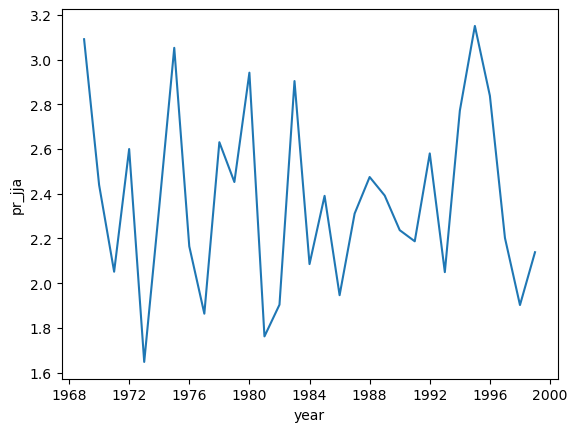

In [25]:
pre1_jja.plot()

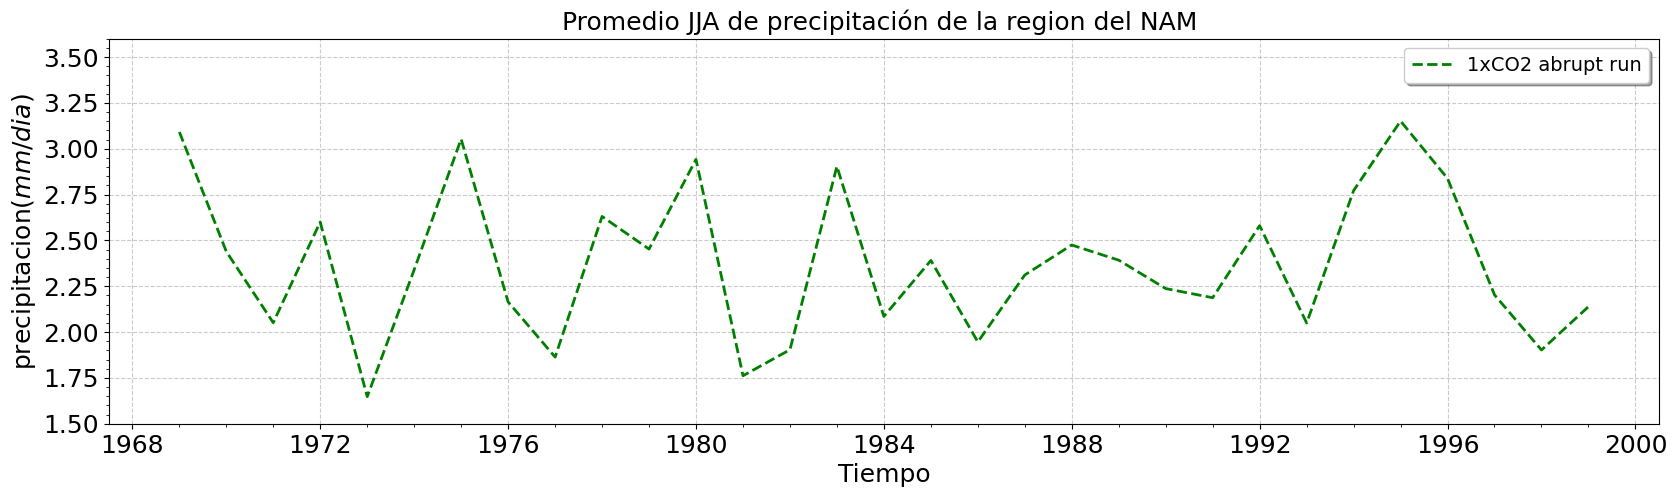

In [26]:
plt.figure(figsize=(20,5))
plt.plot(precip1_jja.year,pre1_jja,c='green',label='1xCO2 abrupt run',linewidth=2,linestyle='dashed')
grafico_linea_ts(None,None,'Tiempo','precipitacion($mm /dia$)','Promedio JJA de precipitación de la region del NAM ',ymin=1.5,ymax=3.6,legend=True)

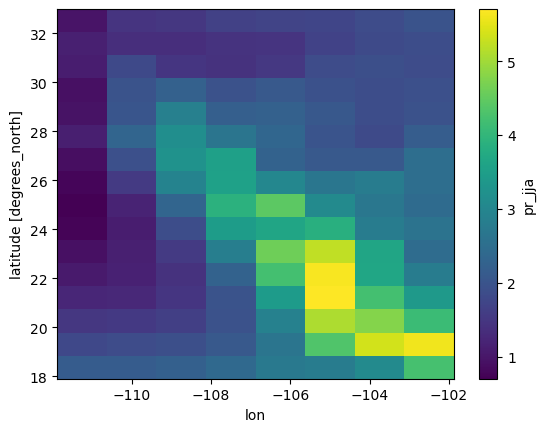

In [27]:
JJA_1=p1_jja.mean(("year"), skipna= True)
JJA_1.plot()

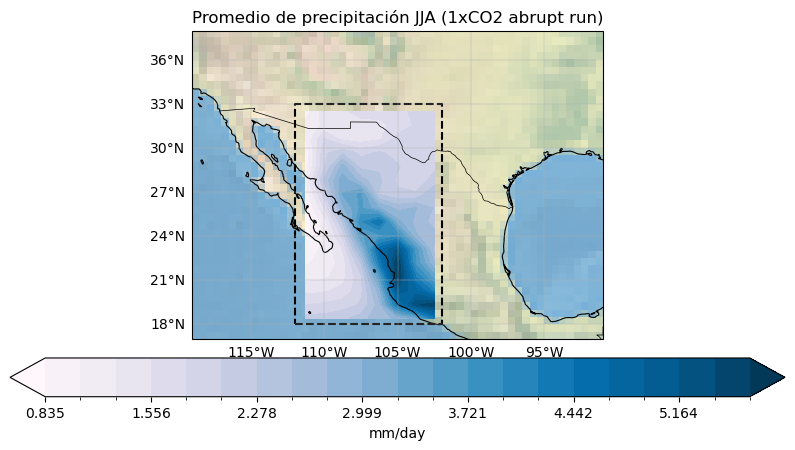

In [28]:
levels = np.linspace(float(JJA_1.quantile(0.02)), float(JJA_1.quantile(0.99)), 21)


fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)




cf = JJA_1.plot.contourf(ax=ax,transform=ccrs.PlateCarree(),
                      levels=levels, add_colorbar=False,cmap='PuBu', extend="both")
lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=p1_jja.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación JJA (1xCO2 abrupt run)")
#plt.savefig('Datos filtrados/Promedio de precipitación Anual .png')
plt.show()

In [29]:
## Datos con aumento por 2 veces de CO2
pr2= xr.open_dataset('pr_2xCO2_run_cesm1-lens_1850-1999.nc')

In [30]:
## Cambio de flotante a datetime 64
## Cambio de float64 a float32 para el promedio anual y el promedio de los meses de junio julio y agosto

pr2['year'] = [pd.Timestamp(str(t)) for t in pr2['year'].values]
pr2['pr'] = pr2['pr'].astype('float32')
pr2['pr_jja']= pr2['pr_jja'].astype('float32')

In [31]:
pr2

<xarray.Dataset> Size: 531MB
Dimensions:     (year: 150, lat: 192, lon: 288)
Coordinates:
  * year        (year) datetime64[ns] 1kB 1850-01-01 1851-01-01 ... 1999-01-01
  * lat         (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon         (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
Data variables:
    pr          (year, lat, lon) float32 33MB 0.1751 0.1751 ... 0.6454 0.6452
    pr_djf      (year, lat, lon) float64 66MB ...
    pr_jja      (year, lat, lon) float32 33MB 0.2208 0.2208 ... 0.5339 0.5335
    pr_max      (year, lat, lon) float64 66MB ...
    pr_max_djf  (year, lat, lon) float64 66MB ...
    pr_max_jja  (year, lat, lon) float64 66MB ...
    tas         (year, lat, lon) float64 66MB ...
    tas_djf     (year, lat, lon) float64 66MB ...
    tas_jja     (year, lat, lon) float64 66MB ...
    weight      (lat, lon) float64 442kB ...

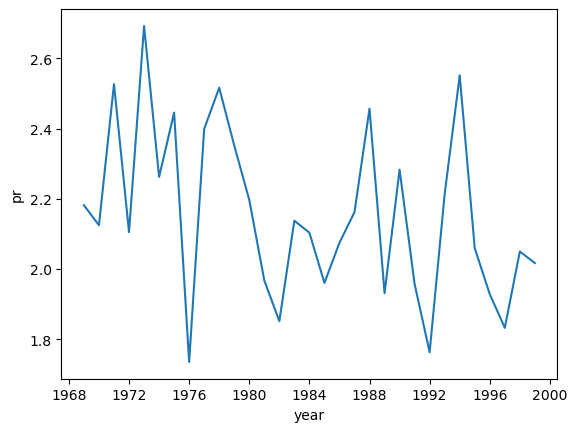

In [32]:
## Precipitacion promedio anual de 2 veces CO2
year2=pr2['year']
precip2=pr2.pr
precip2 = precip2.assign_coords(lon=((precip2.lon + 180) % 360) - 180).sortby('lon')
precip2=precip2.sel(year=slice("1969-01-01", "1999-12-31"))
#precip2= precip2.where((year2 >= 1970) & (year2 <= 1999), drop=True)
p2 = precip2.sel(lon=slice(-112, -102), lat=slice(18, 33))


pre2= p2.mean(('lat','lon'))
pre2.plot()

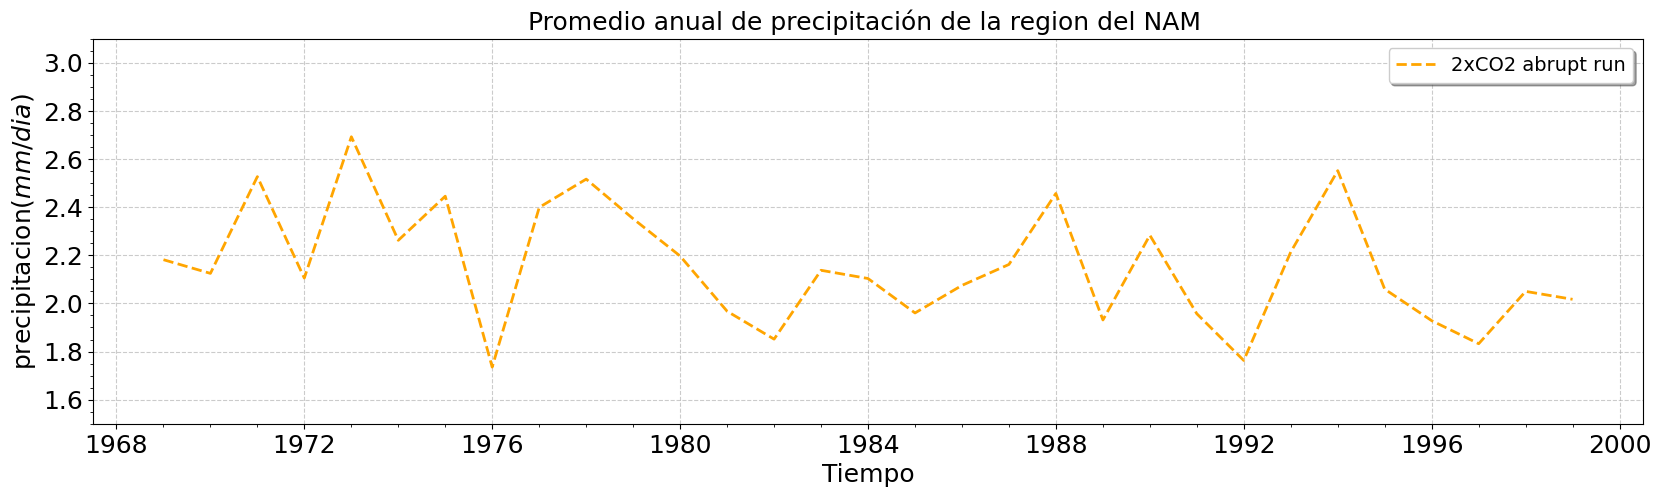

In [33]:
plt.figure(figsize=(20,5))
plt.plot(precip2.year,pre2,c='orange',label='2xCO2 abrupt run',linewidth=2,linestyle='dashed')
grafico_linea_ts(None,None,'Tiempo','precipitacion($mm /dia$)','Promedio anual de precipitación de la region del NAM ',ymin=1.5,ymax=3.1,legend=True)

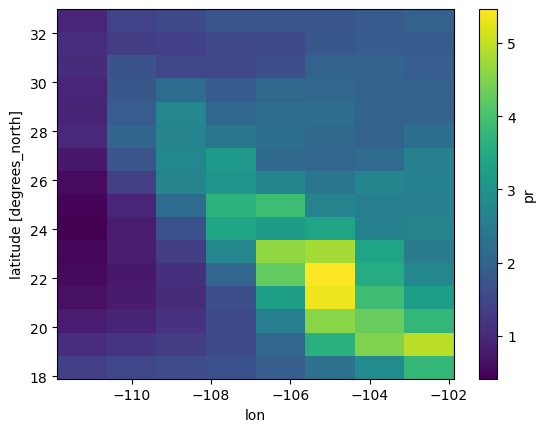

In [34]:

Anual_2=p2.mean(("year"), skipna= True)
Anual_2.plot()

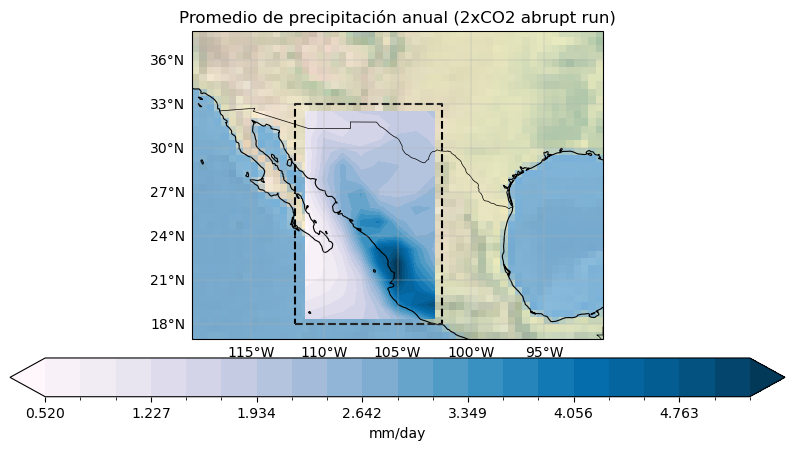

In [35]:
levels = np.linspace(float(Anual_2.quantile(0.02)), float(Anual_2.quantile(0.99)), 21)


fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)




cf = Anual_2.plot.contourf(ax=ax,transform=ccrs.PlateCarree(),
                      levels=levels, add_colorbar=False,cmap='PuBu', extend="both")
lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=precip2.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación anual (2xCO2 abrupt run)")
plt.show()

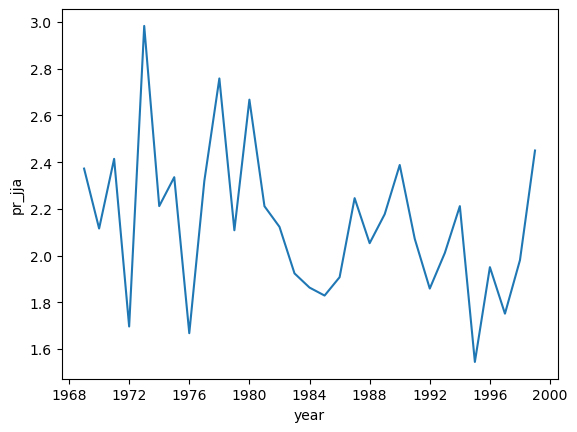

In [36]:
## Precipitación promedio de jja con 2 veces CO2
precip2_jja=pr2.pr_jja
precip2_jja = precip2_jja.assign_coords(lon=((precip2_jja.lon + 180) % 360) - 180).sortby('lon')
precip2_jja=precip2_jja.sel(year=slice("1969-01-01", "1999-12-31"))
#precip2_jja= precip2_jja.where((year2 >= 1970) & (year2 <= 1999), drop=True)
p2_jja = precip2_jja.sel(lon=slice(-112, -102), lat=slice(18, 33))

pre2_jja= p2_jja.mean(('lat','lon'))
pre2_jja.plot()

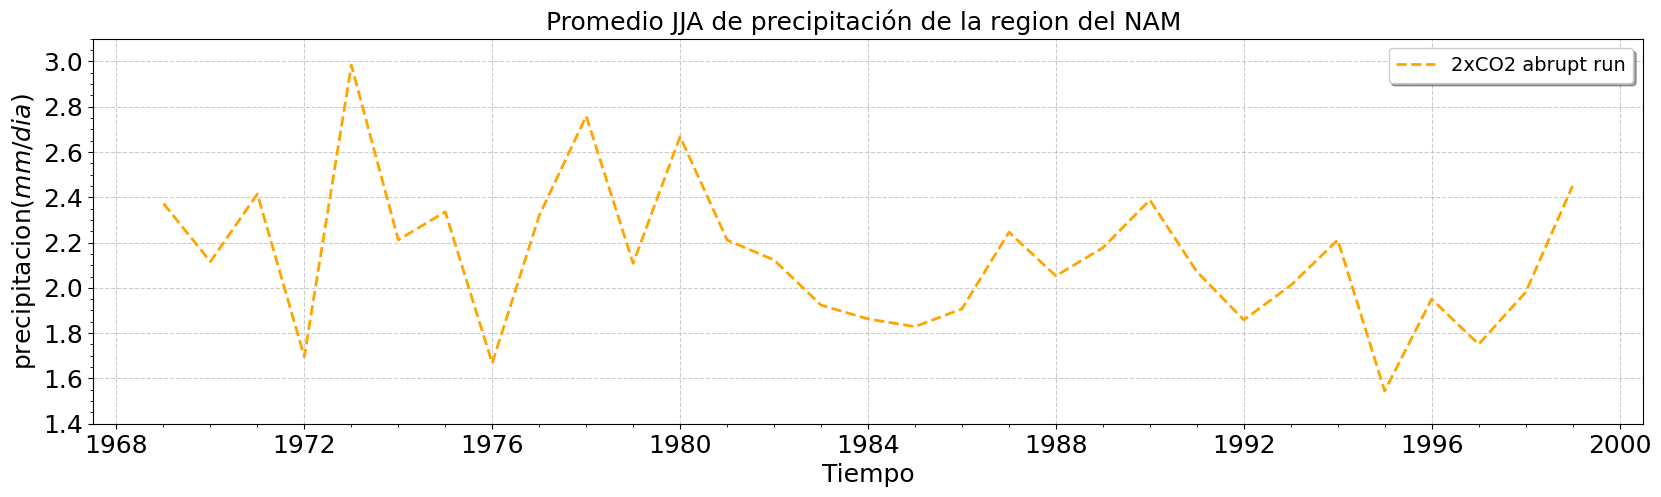

In [37]:
plt.figure(figsize=(20,5))
plt.plot(precip2_jja.year,pre2_jja,c='orange',label='2xCO2 abrupt run',linewidth=2,linestyle='dashed')
grafico_linea_ts(None,None,'Tiempo','precipitacion($mm /dia$)','Promedio JJA de precipitación de la region del NAM ',ymin=1.4,ymax=3.1,legend=True)

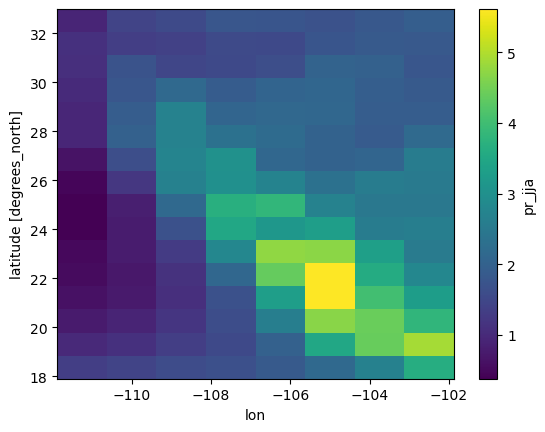

In [38]:
JJA_2=p2_jja.mean(("year"), skipna= True)
JJA_2.plot()

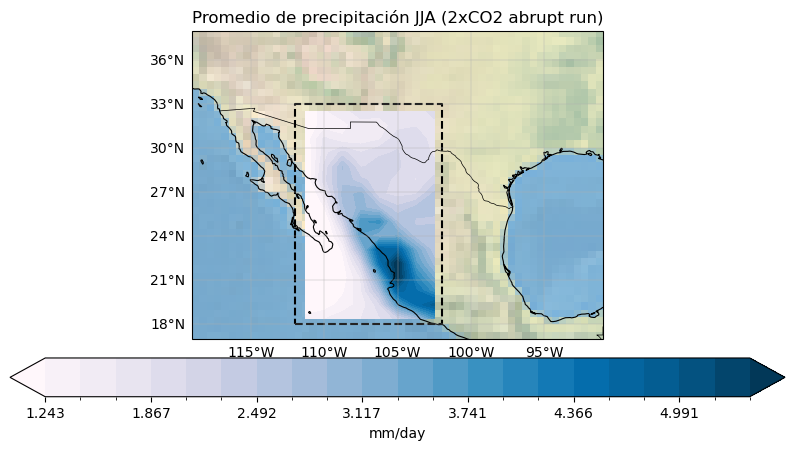

In [39]:
levels = np.linspace(float(JJA_2.quantile(0.2)), float(JJA_2.quantile(0.99)), 21)


fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)




cf = JJA_2.plot.contourf(ax=ax,transform=ccrs.PlateCarree(),
                      levels=levels, add_colorbar=False,cmap='PuBu', extend="both")
lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=precip2_jja.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación JJA (2xCO2 abrupt run)")
plt.show()

In [40]:
## Carga de los datos de 3 veces CO2

pr3= xr.open_dataset('pr_3xCO2_run_cesm1-lens_1850-1999.nc')
pr3['year'] = [pd.Timestamp(str(t)) for t in pr3['year'].values]
pr3['pr'] = pr3['pr'].astype('float32')
pr3['pr_jja']= pr3['pr_jja'].astype('float32')

pr3=pr3.assign_coords(lon=((pr3.lon + 180) % 360) - 180).sortby('lon')
year3=pr3['year']

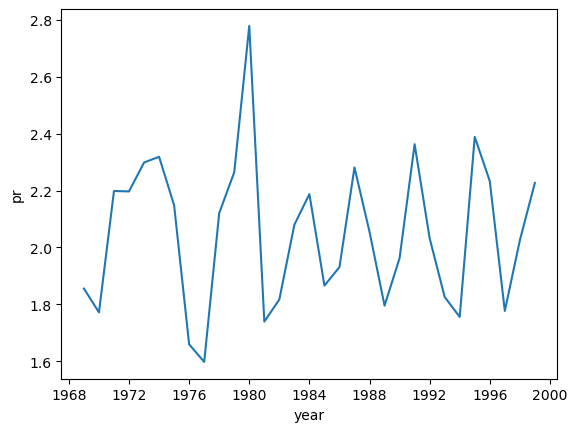

In [41]:
## Precipitacion promedio anual de 3 veces CO2
precip3=pr3.pr
precip3=precip3.sel(year=slice("1969-01-01", "1999-12-31"))

#precip3= precip3.where((year3 >= 1970) & (year3 <= 1999), drop=True)


p3 = precip3.sel(lon=slice(-112, -102), lat=slice(18, 33))
pre3= p3.mean(('lat','lon'))
pre3.plot()

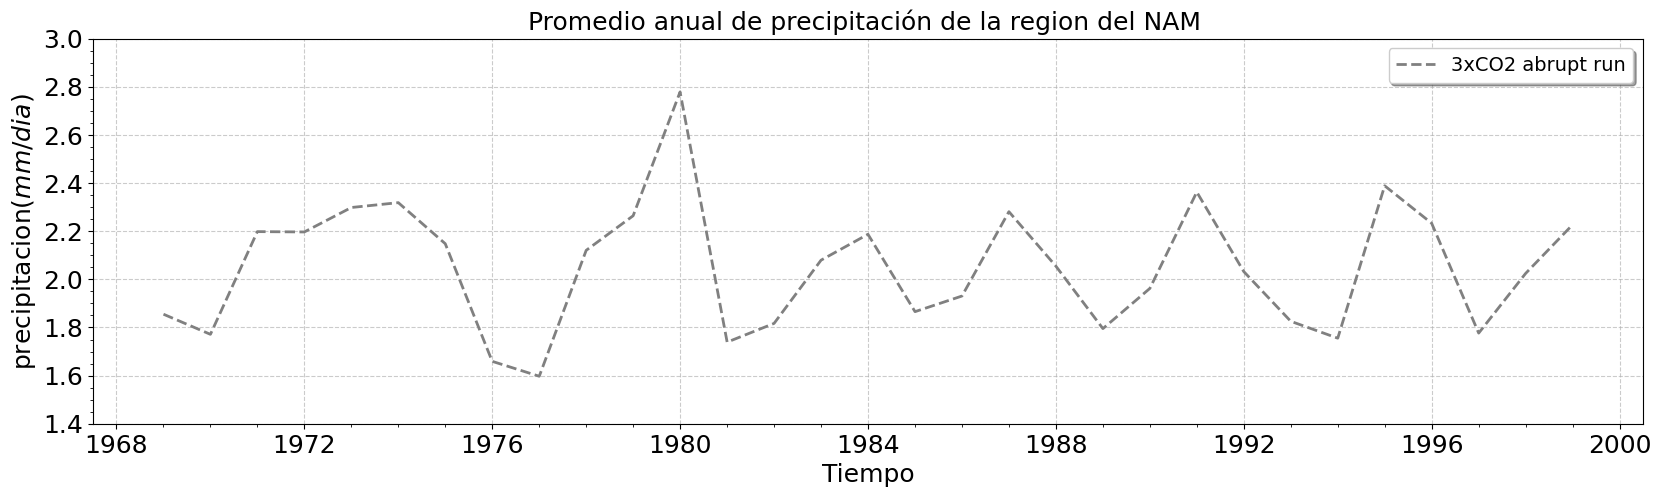

In [42]:
plt.figure(figsize=(20,5))
plt.plot(precip3.year,pre3,c='grey',label='3xCO2 abrupt run',linewidth=2,linestyle='dashed')
grafico_linea_ts(None,None,'Tiempo','precipitacion($mm /dia$)','Promedio anual de precipitación de la region del NAM ',ymin=1.4,ymax=3,legend=True)


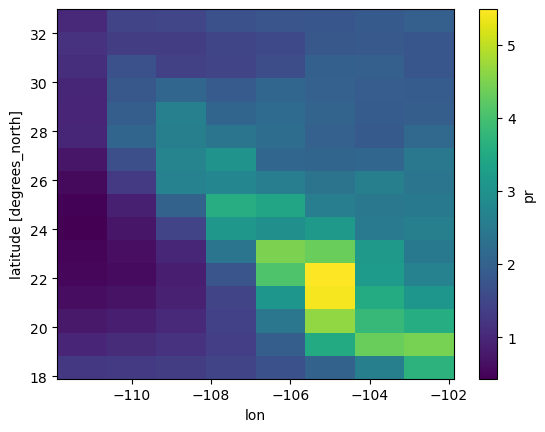

In [43]:
Anual_3=p3.mean(("year"), skipna= True)
Anual_3.plot()

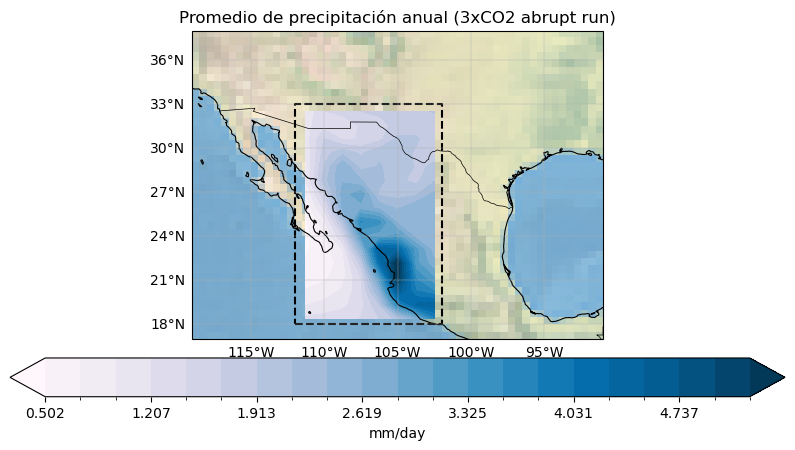

In [44]:

levels = np.linspace(float(Anual_3.quantile(0.02)), float(Anual_3.quantile(0.99)), 21)


fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)




cf = Anual_3.plot.contourf(ax=ax,transform=ccrs.PlateCarree(),
                      levels=levels, add_colorbar=False,cmap='PuBu', extend="both")
lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=precip3.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación anual (3xCO2 abrupt run)")
plt.show()

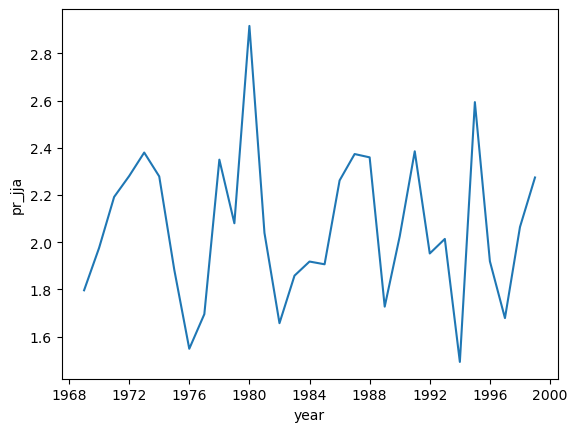

In [45]:
precip3_jja=pr3.pr_jja


precip3_jja=precip3_jja.sel(year=slice("1969-01-01", "1999-12-31"))
#precip3_jja= precip3_jja.where((year3 >= 1970) & (year3 <= 1999), drop=True)



p3_jja = precip3_jja.sel(lon=slice(-112, -102), lat=slice(18, 33))
pre3_jja= p3_jja.mean(('lat','lon'))
pre3_jja.plot()

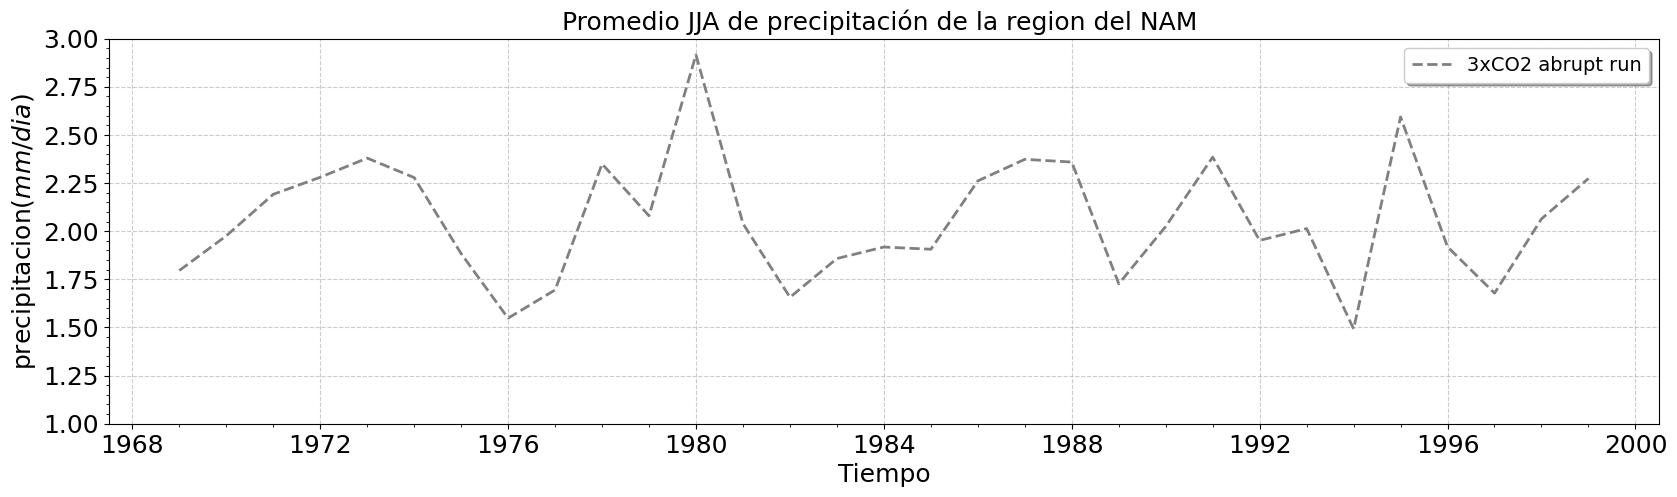

In [46]:

plt.figure(figsize=(20,5))
plt.plot(precip3_jja.year,pre3_jja,c='grey',label='3xCO2 abrupt run',linewidth=2,linestyle='dashed')
grafico_linea_ts(None,None,'Tiempo','precipitacion($mm /dia$)','Promedio JJA de precipitación de la region del NAM ',ymin=1,ymax=3,legend=True)

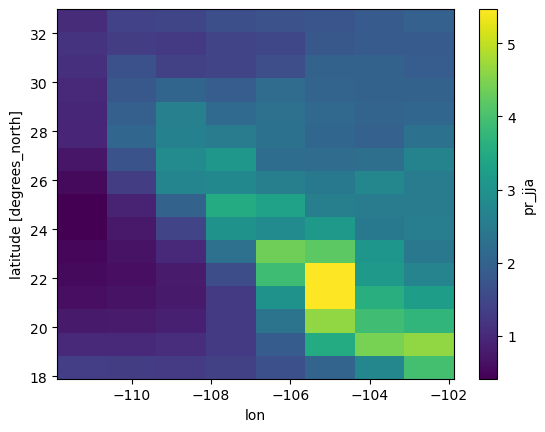

In [47]:
JJA_3=p3_jja.mean(("year"), skipna= True)
JJA_3.plot()

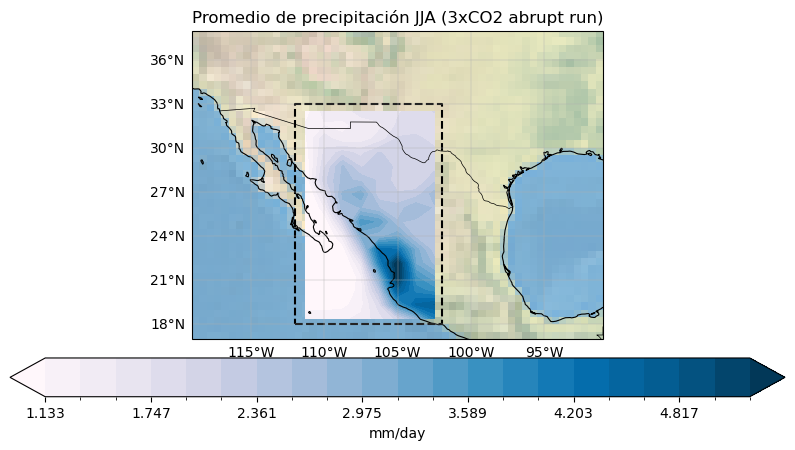

In [48]:
levels = np.linspace(float(JJA_3.quantile(0.2)), float(JJA_3.quantile(0.99)), 21)


fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)




cf = JJA_3.plot.contourf(ax=ax,transform=ccrs.PlateCarree(),
                      levels=levels, add_colorbar=False,cmap='PuBu', extend="both")
lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=precip3_jja.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación JJA (3xCO2 abrupt run)")
plt.show()

In [49]:
## Carga de los datos de 4 veces CO2
pr4= xr.open_dataset('pr_4xCO2_run_cesm1-lens_1850-1999.nc')
pr4['year'] = [pd.Timestamp(str(t)) for t in pr4['year'].values]
pr4['pr'] = pr4['pr'].astype('float32')
pr4['pr_jja']= pr4['pr_jja'].astype('float32')
pr4=pr4.assign_coords(lon=((pr4.lon + 180) % 360) - 180).sortby('lon')

year4=pr4['year']

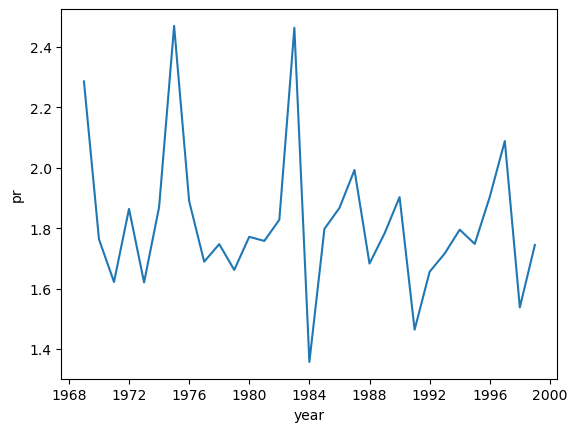

In [50]:
## Precipitacion promedio anual de 4 veces CO2
precip4=pr4.pr

precip4=precip4.sel(year=slice("1969-01-01", "1999-12-31"))
#precip4= precip4.where((year4 >= 1970) & (year4 <= 1999), drop=True)
p4 = precip4.sel(lon=slice(-112, -102), lat=slice(18, 33))
pre4= p4.mean(('lat','lon'))
pre4.plot()

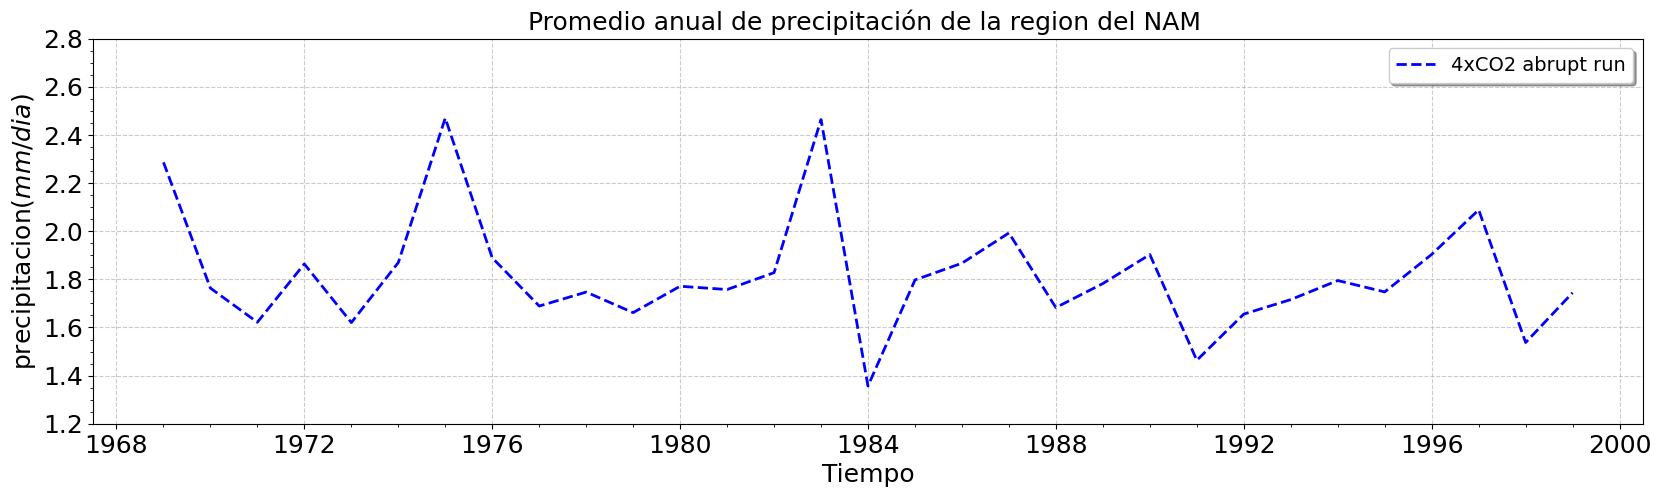

In [51]:
plt.figure(figsize=(20,5))
plt.plot(precip4.year,pre4,c='blue',label='4xCO2 abrupt run',linewidth=2,linestyle='dashed')
grafico_linea_ts(None,None,'Tiempo','precipitacion($mm /dia$)','Promedio anual de precipitación de la region del NAM ',ymin=1.2,ymax=2.8,legend=True)


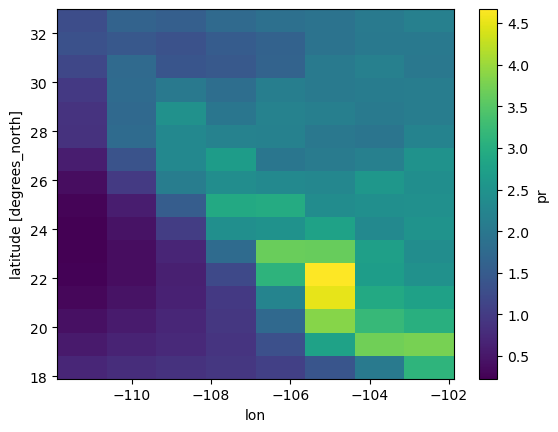

In [52]:
Anual_4=p4.mean(("year"), skipna= True)
Anual_4.plot()

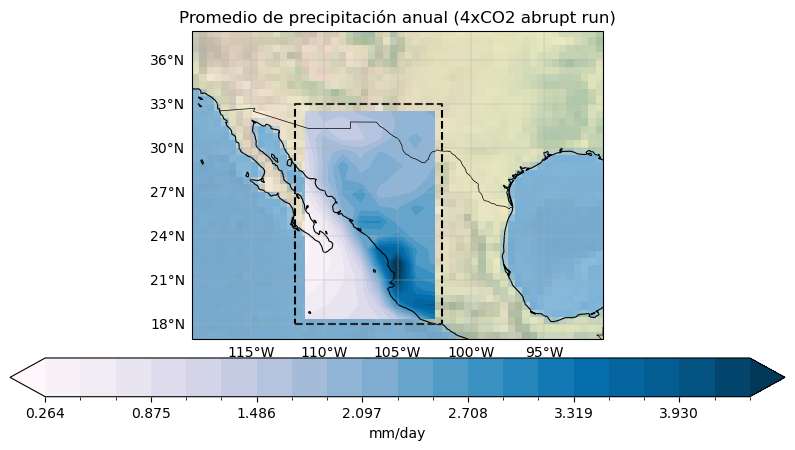

In [53]:

levels = np.linspace(float(Anual_4.quantile(0.02)), float(Anual_4.quantile(0.99)), 21)


fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)




cf = Anual_4.plot.contourf(ax=ax,transform=ccrs.PlateCarree(),
                      levels=levels, add_colorbar=False,cmap='PuBu', extend="both")
lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=precip4.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación anual (4xCO2 abrupt run)")
plt.show()

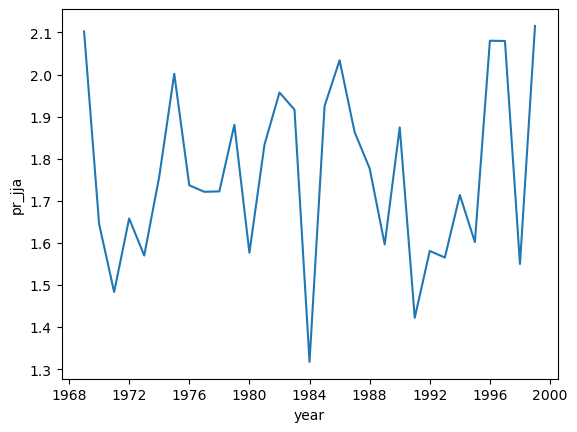

In [54]:
precip4_jja=pr4.pr_jja

precip4_jja=precip4_jja.sel(year=slice("1969-01-01", "1999-12-31"))
#precip4_jja= precip4_jja.where((year4 >= 1970) & (year4 <= 1999), drop=True)

p4_jja = precip4_jja.sel(lon=slice(-112, -102), lat=slice(18, 33))
pre4_jja= p4_jja.mean(('lat','lon'))
pre4_jja.plot()

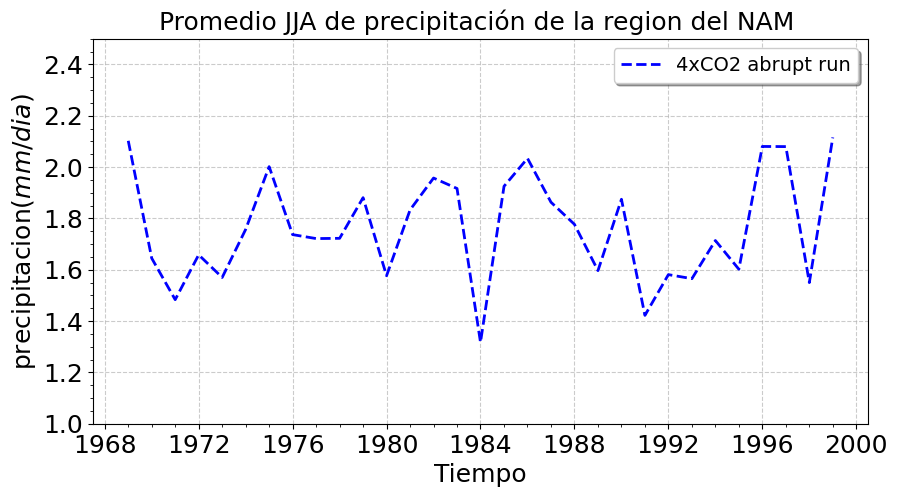

In [55]:
plt.figure(figsize=(10,5))
plt.plot(precip4_jja.year,pre4_jja,c='blue',label='4xCO2 abrupt run',linewidth=2,linestyle='dashed')
grafico_linea_ts(None,None,'Tiempo','precipitacion($mm /dia$)','Promedio JJA de precipitación de la region del NAM ',ymin=1,ymax=2.5,legend=True)

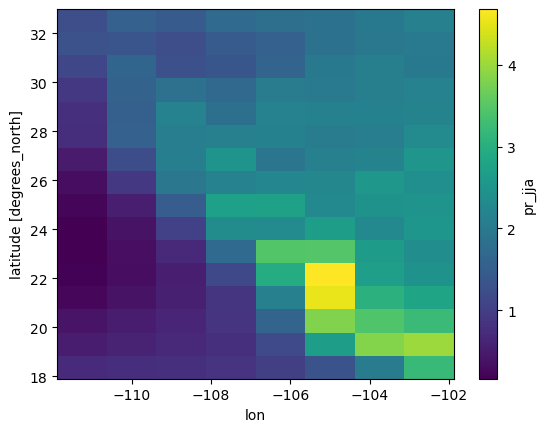

In [56]:
JJA_4=p4_jja.mean(("year"), skipna= True)
JJA_4.plot()

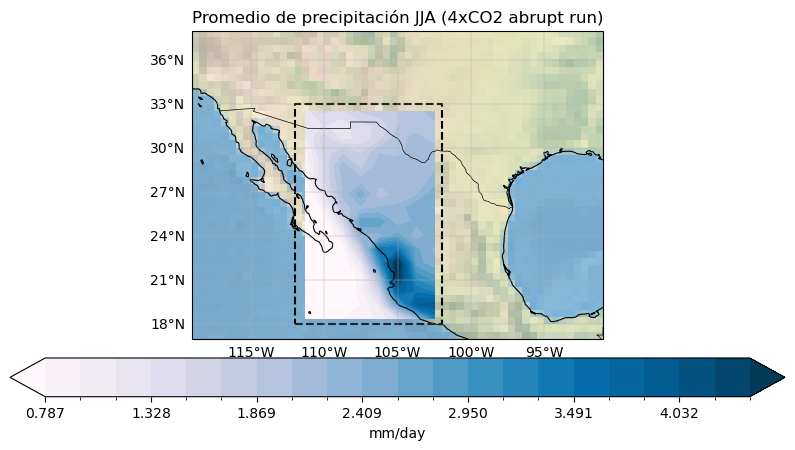

In [57]:
levels = np.linspace(float(JJA_4.quantile(0.2)), float(JJA_4.quantile(0.99)), 21)


fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)




cf = JJA_4.plot.contourf(ax=ax,transform=ccrs.PlateCarree(),
                      levels=levels, add_colorbar=False,cmap='PuBu', extend="both")
lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=precip4_jja.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación JJA (4xCO2 abrupt run)")
plt.show()

In [58]:
## Carga de los datos de 5 veces CO2
pr5= xr.open_dataset('pr_5xCO2_run_cesm1-lens_1850-1999.nc')
pr5['year'] = [pd.Timestamp(str(t)) for t in pr5['year'].values]
pr5['pr'] = pr5['pr'].astype('float32')
pr5['pr_jja']= pr5['pr_jja'].astype('float32')
pr5=pr5.assign_coords(lon=((pr5.lon + 180) % 360) - 180).sortby('lon')
year5=pr5['year']



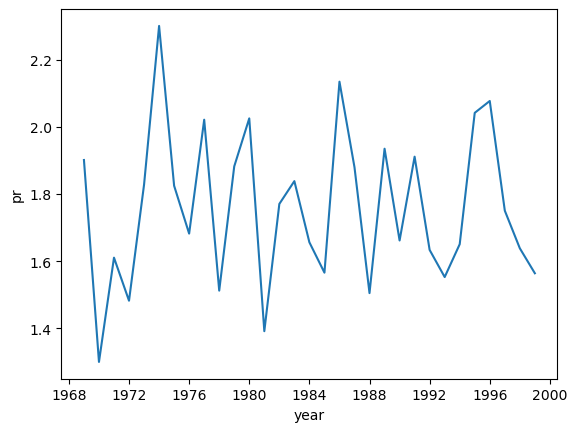

In [59]:
## Precipitacion promedio anual de 4 veces CO2
precip5=pr5.pr

precip5=precip5.sel(year=slice("1969-01-01", "1999-12-31"))

#precip5= precip5.where((year5 >= 1970) & (year5 <= 1999), drop=True)
p5 = precip5.sel(lon=slice(-112, -102), lat=slice(18, 33))
pre5= p5.mean(('lat','lon'))
pre5.plot()

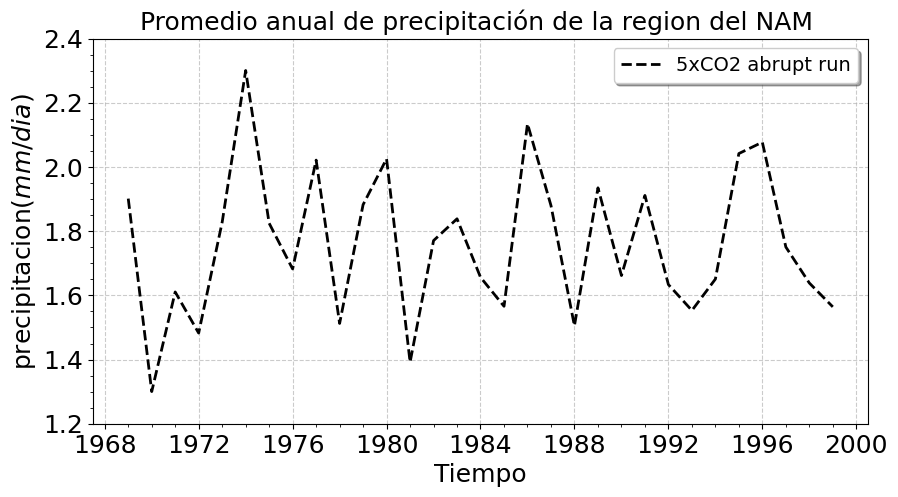

In [60]:
plt.figure(figsize=(10,5))
plt.plot(precip5.year,pre5,c='black',label='5xCO2 abrupt run',linewidth=2,linestyle='dashed')
grafico_linea_ts(None,None,'Tiempo','precipitacion($mm /dia$)','Promedio anual de precipitación de la region del NAM ',ymin=1.2,ymax=2.4,legend=True)


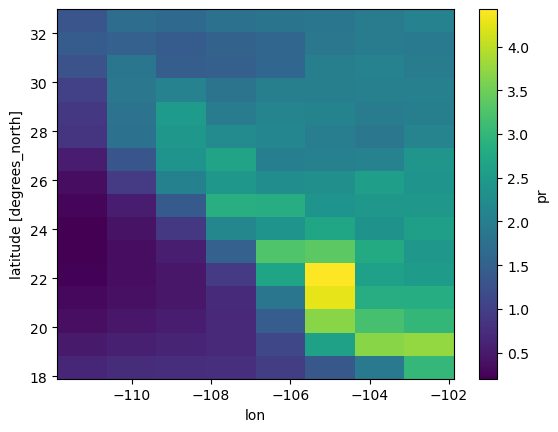

In [61]:
Anual_5=p5.mean(("year"), skipna= True)
Anual_5.plot()

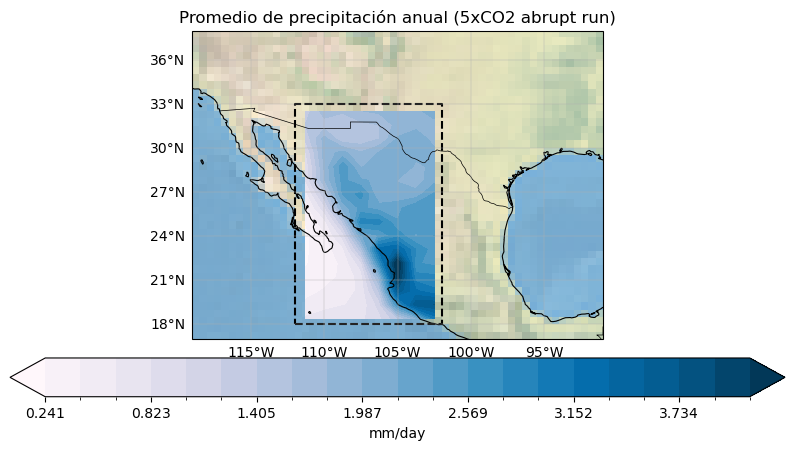

In [62]:
levels = np.linspace(float(Anual_5.quantile(0.02)), float(Anual_5.quantile(0.99)), 21)


fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)




cf = Anual_5.plot.contourf(ax=ax,transform=ccrs.PlateCarree(),
                      levels=levels, add_colorbar=False,cmap='PuBu', extend="both")
lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=precip5.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación anual (5xCO2 abrupt run)")
plt.show()

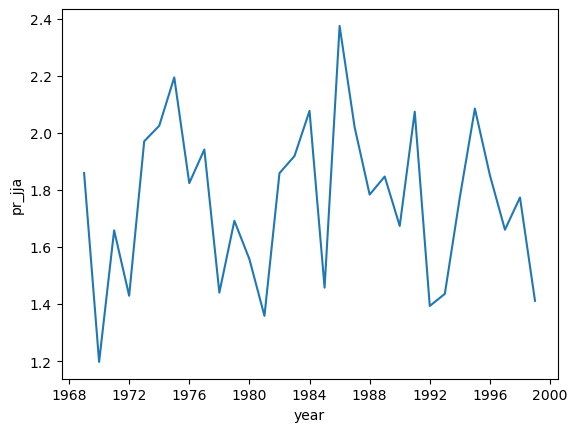

In [63]:
precip5_jja=pr5.pr_jja

precip5_jja=precip5_jja.sel(year=slice("1969-01-01", "1999-12-31"))

#precip5_jja= precip5_jja.where((year5 >= 1970) & (year5 <= 1999), drop=True)
p5_jja = precip5_jja.sel(lon=slice(-112, -102), lat=slice(18, 33))
pre5_jja= p5_jja.mean(('lat','lon'))
pre5_jja.plot()

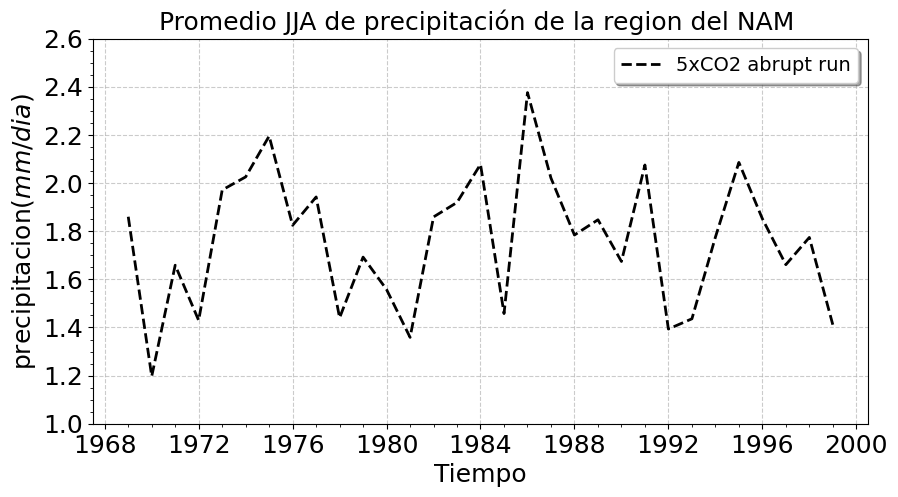

In [64]:
plt.figure(figsize=(10,5))
plt.plot(precip5_jja.year,pre5_jja,c='black',label='5xCO2 abrupt run',linewidth=2,linestyle='dashed')
grafico_linea_ts(None,None,'Tiempo','precipitacion($mm /dia$)','Promedio JJA de precipitación de la region del NAM ',ymin=1,ymax=2.6,legend=True)

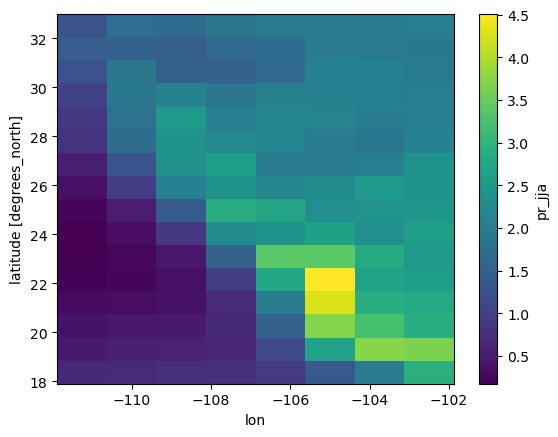

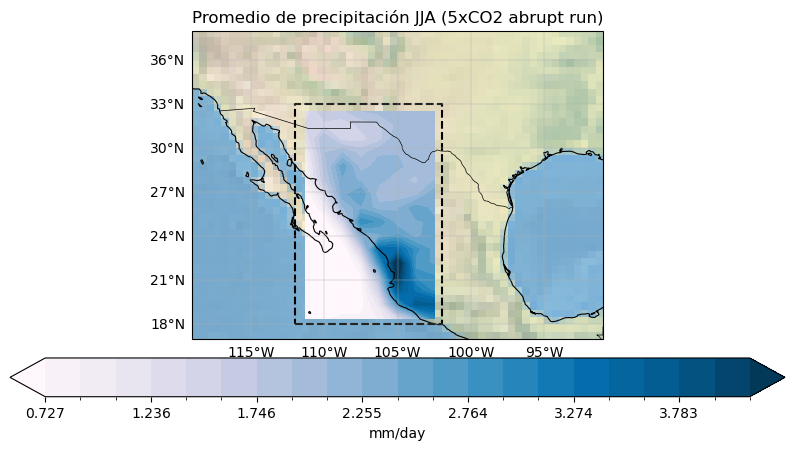

In [65]:
JJA_5=p5_jja.mean(("year"), skipna= True)
JJA_5.plot()
levels = np.linspace(float(JJA_5.quantile(0.2)), float(JJA_5.quantile(0.99)), 21)


fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)




cf = JJA_5.plot.contourf(ax=ax,transform=ccrs.PlateCarree(),
                      levels=levels, add_colorbar=False,cmap='PuBu', extend="both")
lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=precip5_jja.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación JJA (5xCO2 abrupt run)")
plt.show()

In [66]:
## Carga de los datos de 6 veces CO2
pr6= xr.open_dataset('pr_6xCO2_run_cesm1-lens_1850-1999.nc')
pr6['year'] = [pd.Timestamp(str(t)) for t in pr6['year'].values]
pr6['pr'] = pr6['pr'].astype('float32')
pr6['pr_jja']= pr6['pr_jja'].astype('float32')
pr6=pr6.assign_coords(lon=((pr6.lon + 180) % 360) - 180).sortby('lon')

year6=pr6['year']

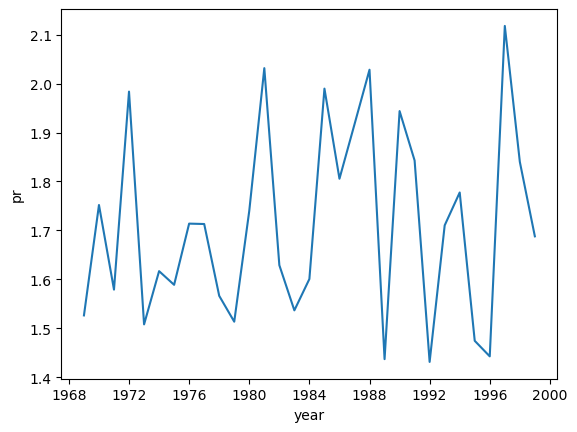

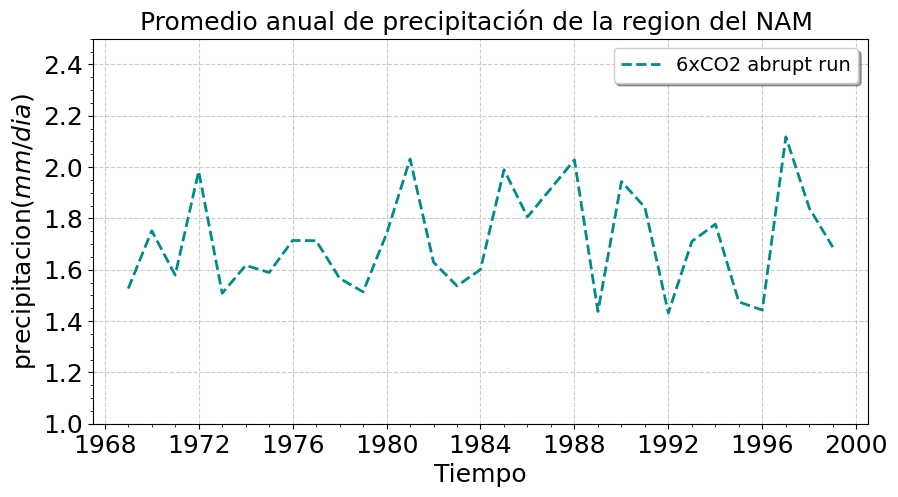

In [67]:
## Precipitacion promedio anual de 6 veces CO2
precip6=pr6.pr

precip6=precip6.sel(year=slice("1969-01-01", "1999-12-31"))

#precip6= precip5.where((year6 >= 1970) & (year6 <= 1999), drop=True)
p6 = precip6.sel(lon=slice(-112, -102), lat=slice(18, 33))
pre6= p6.mean(('lat','lon'))
pre6.plot()

plt.figure(figsize=(10,5))
plt.plot(precip6.year,pre6,c='darkcyan',label='6xCO2 abrupt run',linewidth=2,linestyle='dashed')
grafico_linea_ts(None,None,'Tiempo','precipitacion($mm /dia$)','Promedio anual de precipitación de la region del NAM ',ymin=1,ymax=2.5,legend=True)


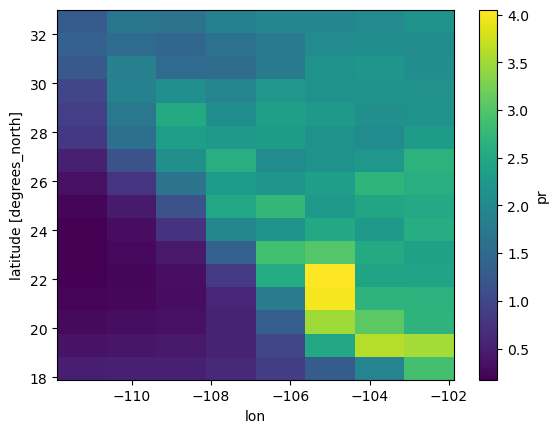

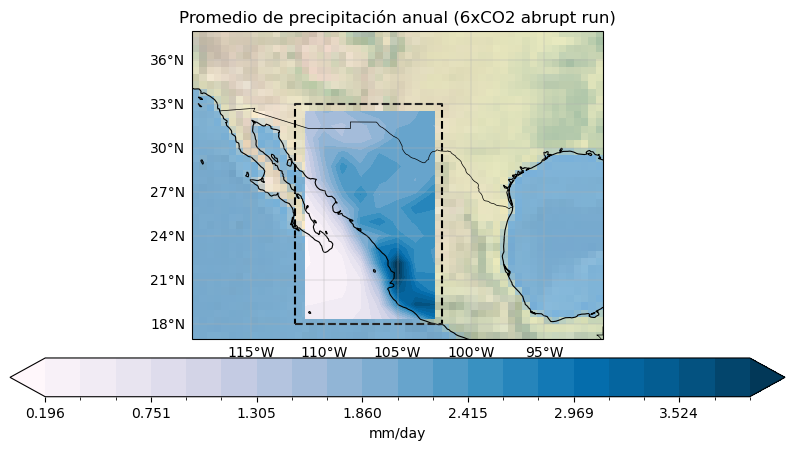

In [68]:
Anual_6=p6.mean(("year"), skipna= True)
Anual_6.plot()
levels = np.linspace(float(Anual_6.quantile(0.02)), float(Anual_6.quantile(0.99)), 21)


fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)




cf = Anual_6.plot.contourf(ax=ax,transform=ccrs.PlateCarree(),
                      levels=levels, add_colorbar=False,cmap='PuBu', extend="both")
lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=precip6.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación anual (6xCO2 abrupt run)")
plt.show()

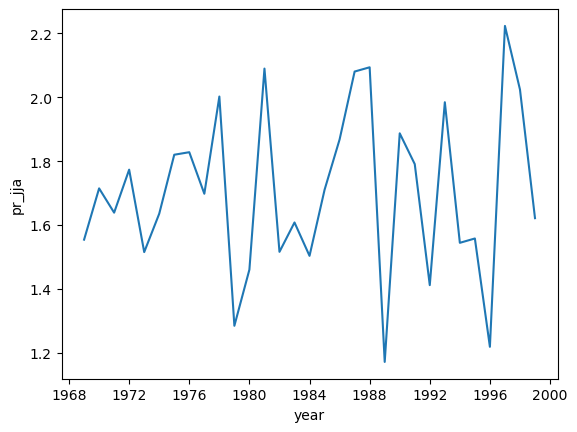

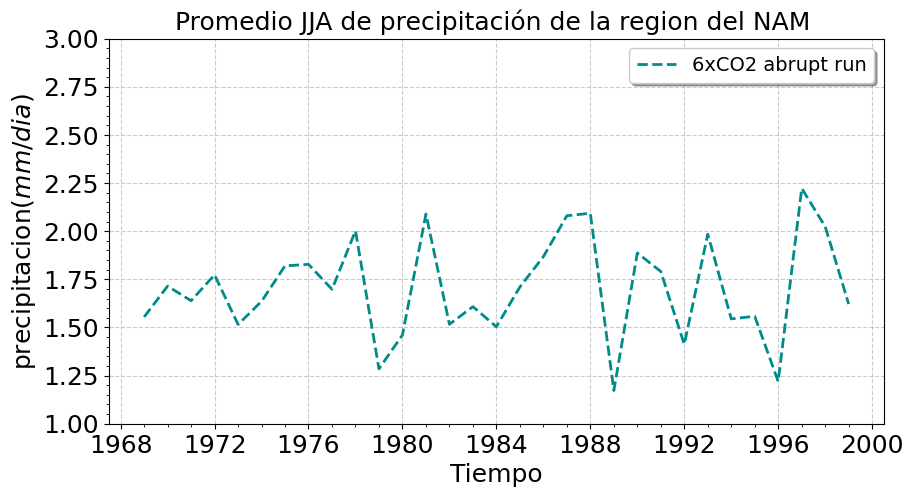

In [69]:
precip6_jja=pr6.pr_jja

precip6_jja=precip6_jja.sel(year=slice("1969-01-01", "1999-12-31"))
#precip6_jja= precip6_jja.where((year6 >= 1970) & (year6 <= 1999), drop=True)
p6_jja = precip6_jja.sel(lon=slice(-112, -102), lat=slice(18, 33))
pre6_jja= p6_jja.mean(('lat','lon'))
pre6_jja.plot()
plt.figure(figsize=(10,5))
plt.plot(precip6_jja.year,pre6_jja,c='darkcyan',label='6xCO2 abrupt run',linewidth=2,linestyle='dashed')
grafico_linea_ts(None,None,'Tiempo','precipitacion($mm /dia$)','Promedio JJA de precipitación de la region del NAM ',ymin=1,ymax=3,legend=True)

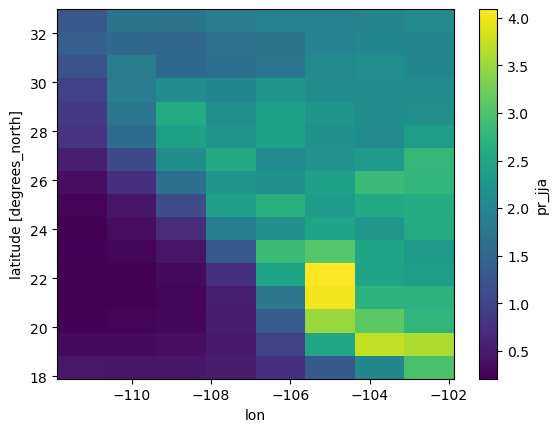

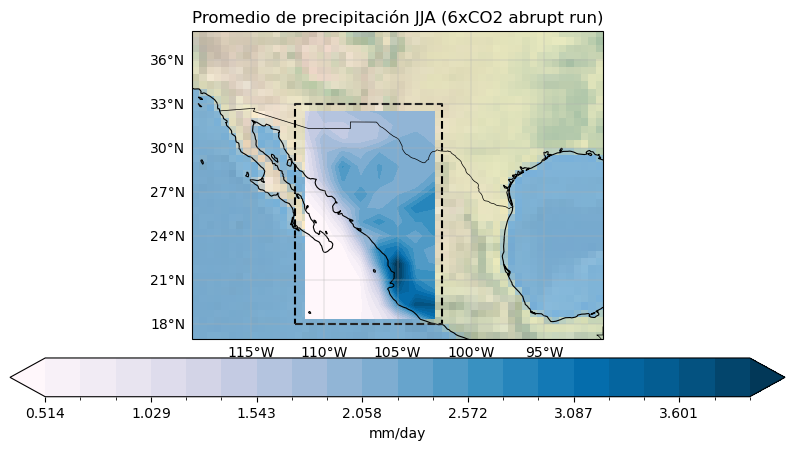

In [70]:
JJA_6=p6_jja.mean(("year"), skipna= True)
JJA_6.plot()
levels = np.linspace(float(JJA_6.quantile(0.2)), float(JJA_6.quantile(0.99)), 21)


fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)




cf = JJA_6.plot.contourf(ax=ax,transform=ccrs.PlateCarree(),
                      levels=levels, add_colorbar=False,cmap='PuBu', extend="both")
lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=precip6_jja.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación JJA (6xCO2 abrupt run)")
plt.show()

In [71]:
## Carga de los datos de 7 veces CO2
pr7= xr.open_dataset('pr_7xCO2_run_cesm1-lens_1850-1999.nc')
pr7['year'] = [pd.Timestamp(str(t)) for t in pr7['year'].values]
pr7['pr'] = pr7['pr'].astype('float32')
pr7['pr_jja']= pr7['pr_jja'].astype('float32')
pr7=pr7.assign_coords(lon=((pr7.lon + 180) % 360) - 180).sortby('lon')
year7=pr7['year']

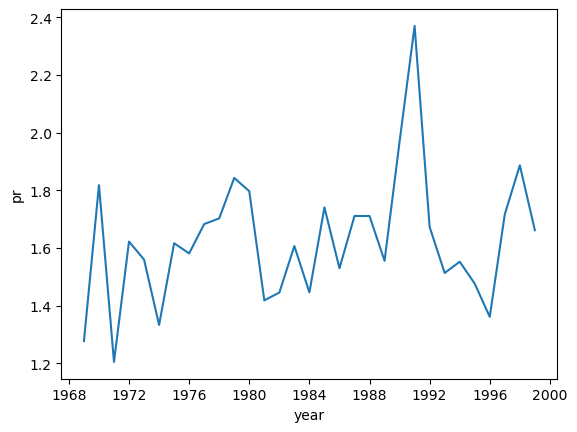

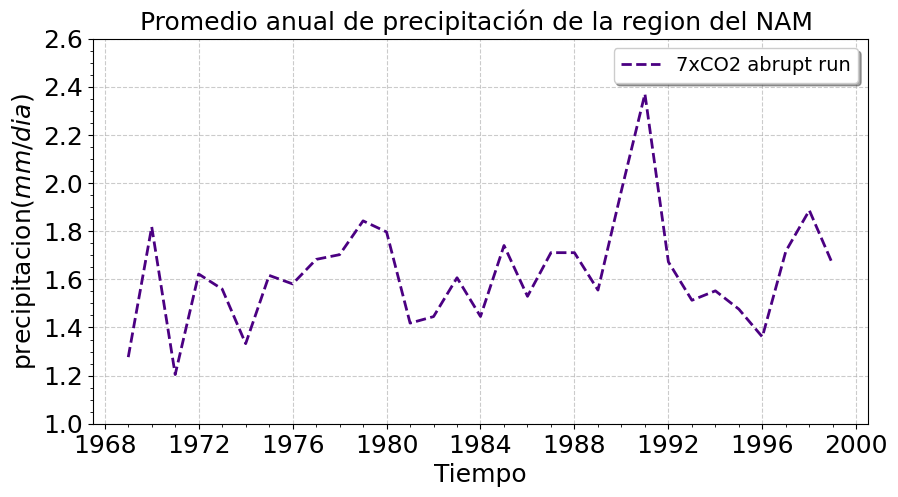

In [72]:
## Precipitacion promedio anual de 7 veces CO2
precip7=pr7.pr

precip7=precip7.sel(year=slice("1969-01-01", "1999-12-31"))

#precip7= precip7.where((year7 >= 1970) & (year7 <= 1999), drop=True)

p7 = precip7.sel(lon=slice(-112, -102), lat=slice(18, 33))
pre7= p7.mean(('lat','lon'))
pre7.plot()

plt.figure(figsize=(10,5))
plt.plot(precip7.year,pre7,c='indigo',label='7xCO2 abrupt run',linewidth=2,linestyle='dashed')
grafico_linea_ts(None,None,'Tiempo','precipitacion($mm /dia$)','Promedio anual de precipitación de la region del NAM ',ymin=1,ymax=2.6,legend=True)


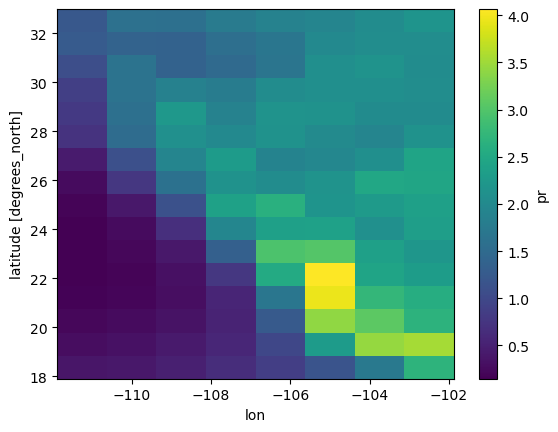

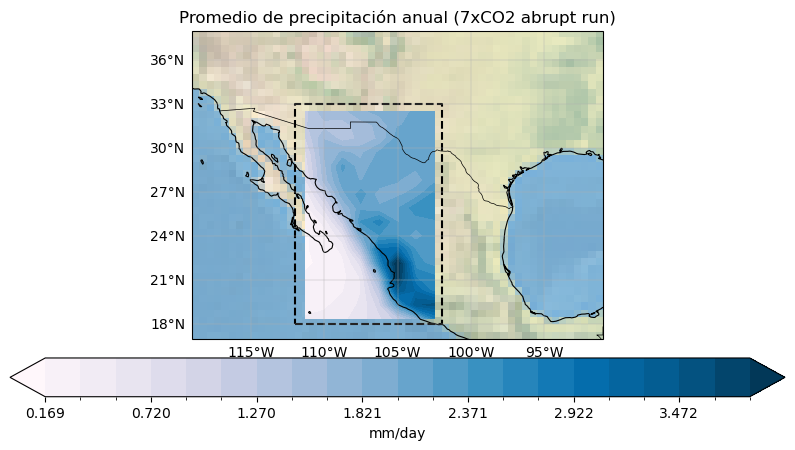

In [73]:
Anual_7=p7.mean(("year"), skipna= True)
Anual_7.plot()
levels = np.linspace(float(Anual_7.quantile(0.02)), float(Anual_7.quantile(0.99)), 21)


fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)




cf = Anual_7.plot.contourf(ax=ax,transform=ccrs.PlateCarree(),
                      levels=levels, add_colorbar=False,cmap='PuBu', extend="both")
lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=precip7.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación anual (7xCO2 abrupt run)")
plt.show()

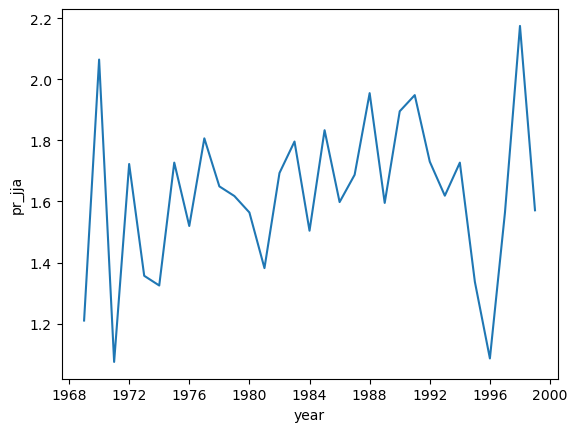

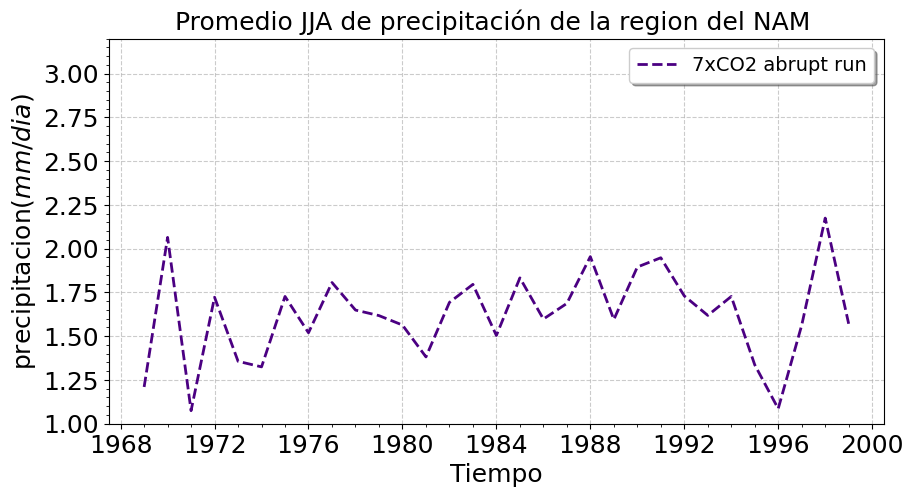

In [74]:
precip7_jja=pr7.pr_jja

precip7_jja=precip7_jja.sel(year=slice("1969-01-01", "1999-12-31"))

#precip7_jja= precip7_jja.where((year7 >= 1970) & (year7 <= 1999), drop=True)

p7_jja = precip7_jja.sel(lon=slice(-112, -102), lat=slice(18, 33))
pre7_jja= p7_jja.mean(('lat','lon'))
pre7_jja.plot()
plt.figure(figsize=(10,5))
plt.plot(precip7_jja.year,pre7_jja,c='indigo',label='7xCO2 abrupt run',linewidth=2,linestyle='dashed')
grafico_linea_ts(None,None,'Tiempo','precipitacion($mm /dia$)','Promedio JJA de precipitación de la region del NAM ',ymin=1,ymax=3.2,legend=True)

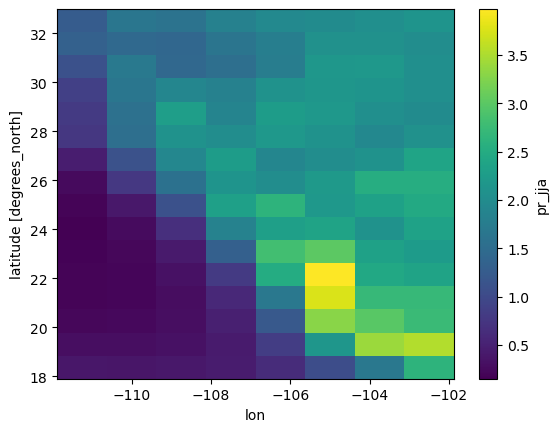

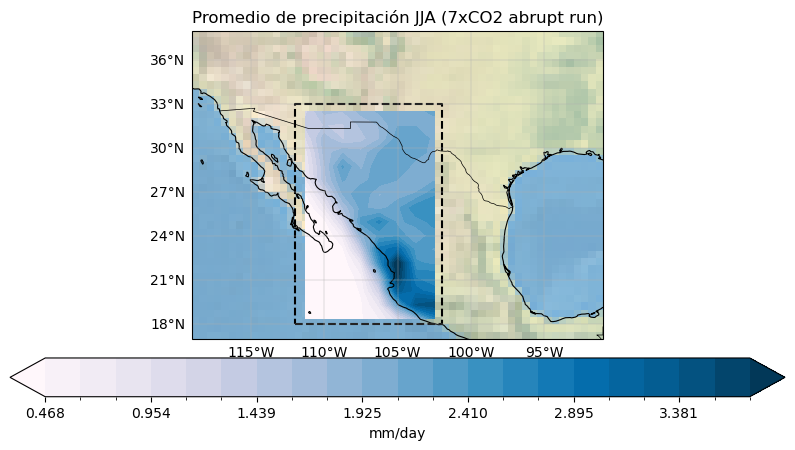

In [75]:
JJA_7=p7_jja.mean(("year"), skipna= True)
JJA_7.plot()
levels = np.linspace(float(JJA_7.quantile(0.2)), float(JJA_7.quantile(0.99)), 21)


fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)




cf = JJA_7.plot.contourf(ax=ax,transform=ccrs.PlateCarree(),
                      levels=levels, add_colorbar=False,cmap='PuBu', extend="both")
lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=precip7_jja.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación JJA (7xCO2 abrupt run)")
plt.show()

In [76]:
## Carga de los datos de 8 veces CO2
pr8= xr.open_dataset('pr_8xCO2_run_cesm1-lens_1850-1999.nc')
pr8['year'] = [pd.Timestamp(str(t)) for t in pr8['year'].values]
pr8['pr'] = pr8['pr'].astype('float32')
pr8['pr_jja']= pr8['pr_jja'].astype('float32')
pr8=pr8.assign_coords(lon=((pr8.lon + 180) % 360) - 180).sortby('lon')

year8=pr8['year']

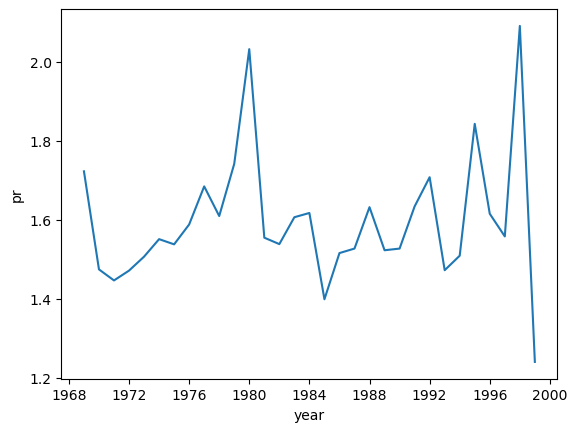

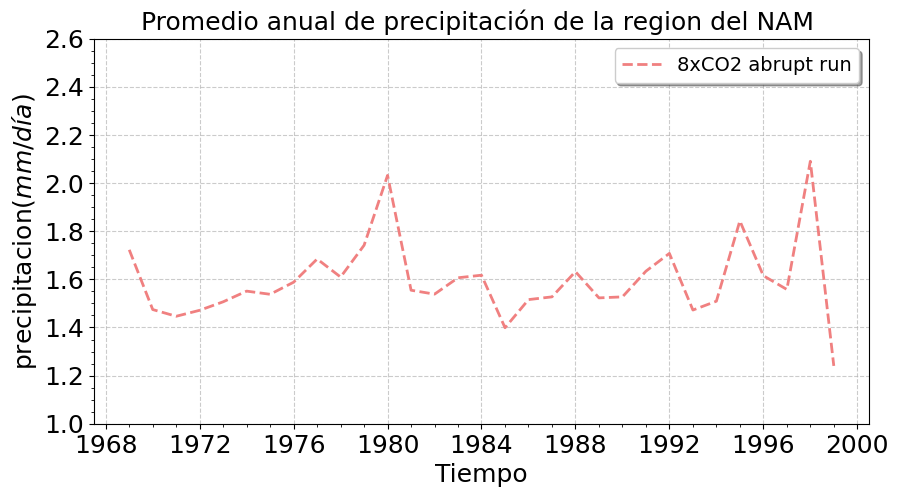

In [77]:
## Precipitacion promedio anual de 7 veces CO2
precip8=pr8.pr

precip8=precip8.sel(year=slice("1969-01-01", "1999-12-31"))

#precip8= precip8.where((year8 >= 1970) & (year8 <= 1999), drop=True)

p8 = precip8.sel(lon=slice(-112, -102), lat=slice(18, 33))
pre8= p8.mean(('lat','lon'))
pre8.plot()

plt.figure(figsize=(10,5))
plt.plot(precip8.year,pre8,c='lightcoral',label='8xCO2 abrupt run',linewidth=2,linestyle='dashed')
grafico_linea_ts(None,None,'Tiempo','precipitacion($mm /día$)','Promedio anual de precipitación de la region del NAM ',ymin=1,ymax=2.6,legend=True)


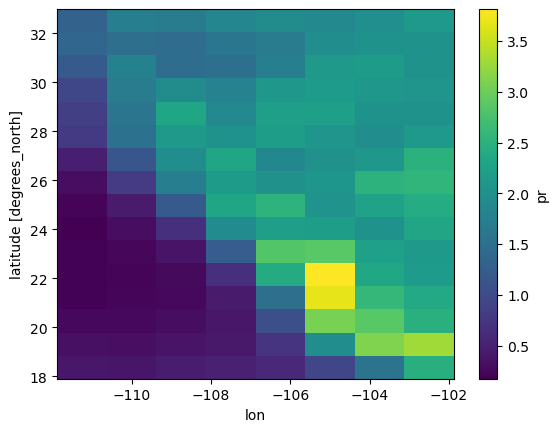

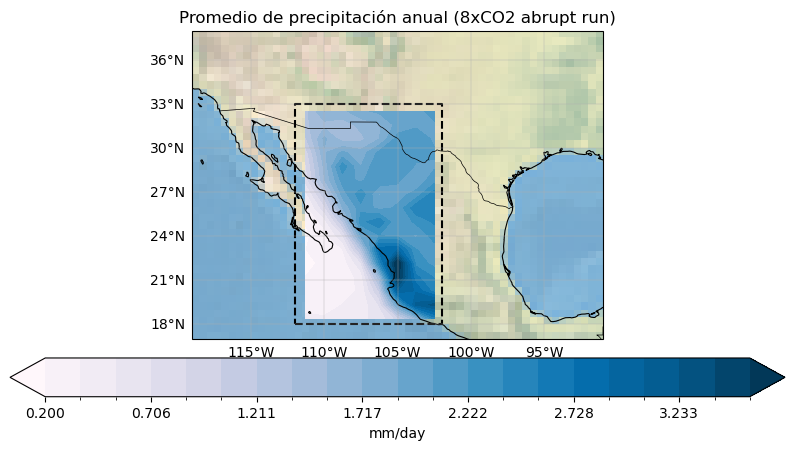

In [78]:
Anual_8=p8.mean(("year"), skipna= True)
Anual_8.plot()
levels = np.linspace(float(Anual_8.quantile(0.02)), float(Anual_8.quantile(0.99)), 21)


fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)




cf = Anual_8.plot.contourf(ax=ax,transform=ccrs.PlateCarree(),
                      levels=levels, add_colorbar=False,cmap='PuBu', extend="both")
lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=precip8.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación anual (8xCO2 abrupt run)")
plt.show()

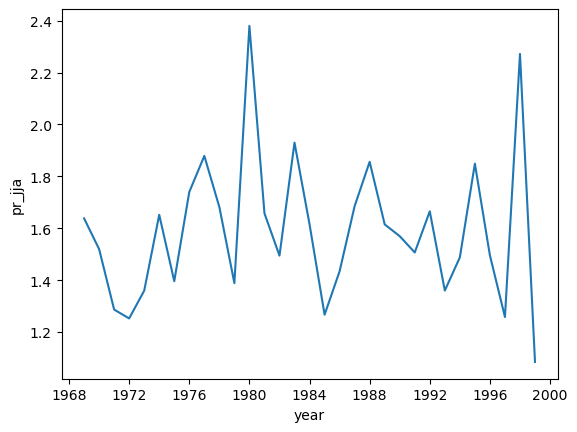

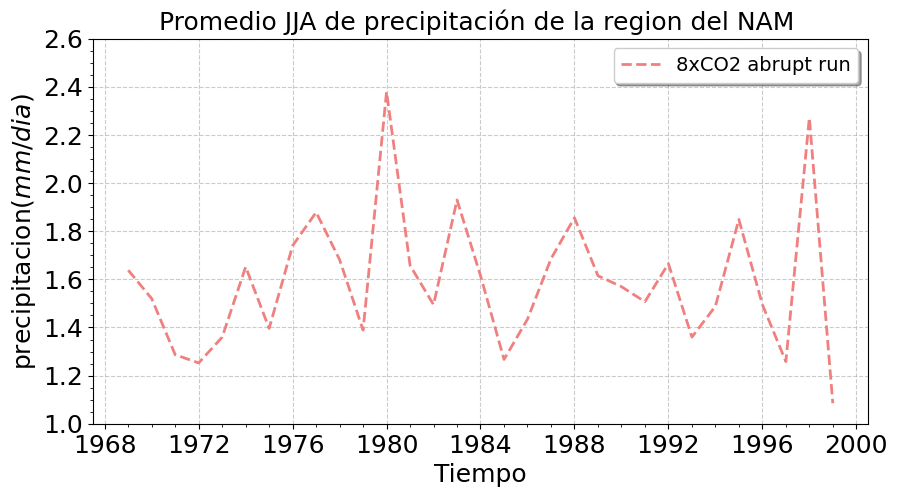

In [79]:
precip8_jja=pr8.pr_jja

precip8_jja=precip8_jja.sel(year=slice("1969-01-01", "1999-12-31"))
#precip8_jja= precip8_jja.where((year8 >= 1970) & (year8 <= 1999), drop=True)

p8_jja = precip8_jja.sel(lon=slice(-112, -102), lat=slice(18, 33))
pre8_jja= p8_jja.mean(('lat','lon'))
pre8_jja.plot()



plt.figure(figsize=(10,5))
plt.plot(precip8_jja.year,pre8_jja,c='lightcoral',label='8xCO2 abrupt run',linewidth=2,linestyle='dashed')
grafico_linea_ts(None,None,'Tiempo','precipitacion($mm /dia$)','Promedio JJA de precipitación de la region del NAM ',ymin=1,ymax=2.6,legend=True)

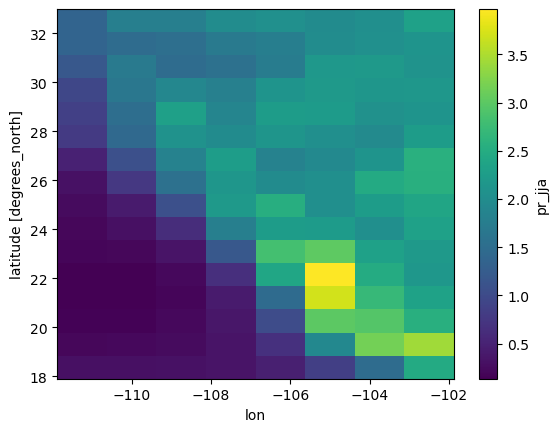

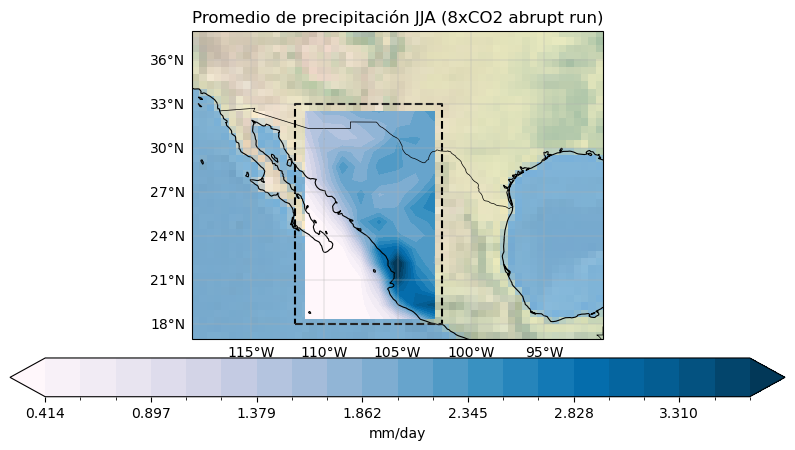

In [80]:
JJA_8=p8_jja.mean(("year"), skipna= True)
JJA_8.plot()
levels = np.linspace(float(JJA_8.quantile(0.2)), float(JJA_8.quantile(0.99)), 21)


fig, ax = plt.subplots(figsize=(10,5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-119, -91, 17, 38], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)




cf = JJA_8.plot.contourf(ax=ax,transform=ccrs.PlateCarree(),
                      levels=levels, add_colorbar=False,cmap='PuBu', extend="both")
lat_min, lat_max = 18, 33
lon_min, lon_max = -112, -102

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    linestyle='--',
    linewidth=1.5,
    color='k'
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label=precip8_jja.attrs.get("units",""))
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3)
gl.right_labels = gl.top_labels = False
ax.stock_img()
ax.set_title("Promedio de precipitación JJA (8xCO2 abrupt run)")
plt.show()

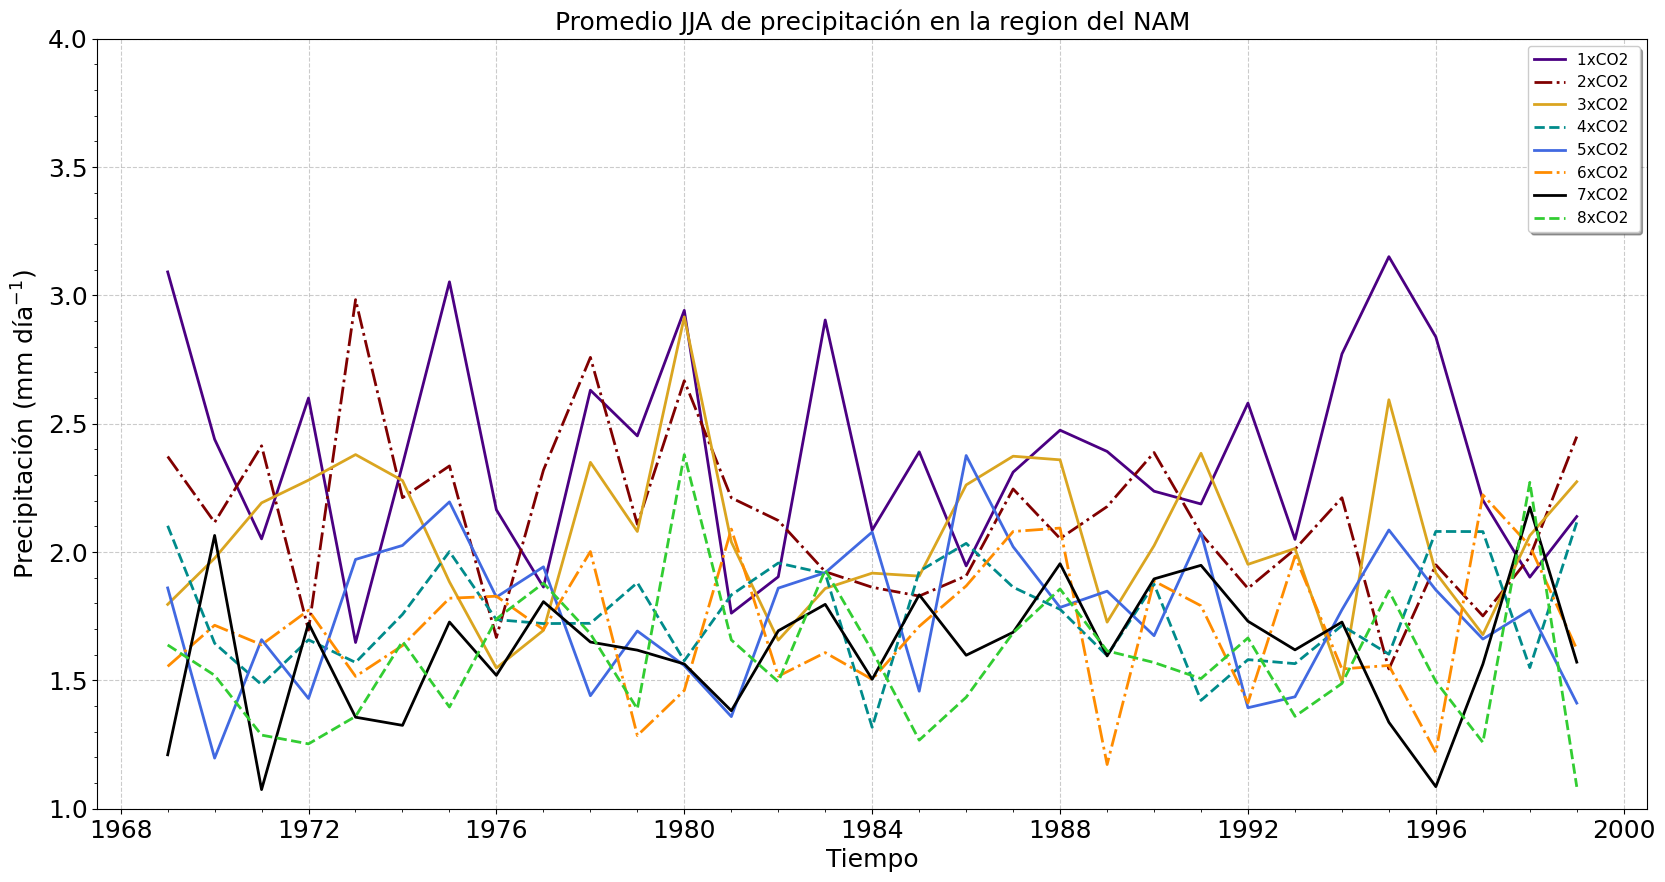

In [124]:
plt.figure(figsize=(20,10))

plt.plot(precip1_jja.year,pre1_jja,c='indigo',label='1xCO2 ',linewidth=2,linestyle='solid')

plt.plot(precip2_jja.year,pre2_jja,c='maroon',label='2xCO2 ',linewidth=2,linestyle='dashdot')

plt.plot(precip3_jja.year,pre3_jja,c='goldenrod',label='3xCO2 ',linewidth=2,linestyle='solid')

plt.plot(precip4_jja.year,pre4_jja,c='darkcyan',label='4xCO2 ',linewidth=2,linestyle='dashed')

plt.plot(precip5_jja.year,pre5_jja,c='royalblue',label='5xCO2 ',linewidth=2,linestyle='solid')

plt.plot(precip6_jja.year,pre6_jja,c='darkorange',label='6xCO2 ',linewidth=2,linestyle='dashdot')

plt.plot(precip7_jja.year,pre7_jja,c='black',label='7xCO2 ',linewidth=2,linestyle='solid')

plt.plot(precip8_jja.year,pre8_jja,c='limegreen',label='8xCO2 ',linewidth=2,linestyle='dashed')





grafico_linea_ts(None, None,xlab='Tiempo',ylab='Precipitación (mm día$^{-1}$)',title='Promedio JJA de precipitación en la region del NAM',ymin=1, ymax=4,legend=True)
plt.savefig('Imagenes/Serie_simulaciones1_8_JJA.png', dpi=300, bbox_inches="tight")
plt.show()

In [82]:
ds= xr.open_dataset('precip.monitor.mon.total.1x1.v2020.nc')

In [83]:
dp= xr.open_dataset('pr_Amon_HadGEM3-GC31-LL_amip_r1i1p1f3_gn_197901-201412.nc')

In [84]:
dp['time'] = [pd.Timestamp(str(t)) for t in dp['time'].values]

In [126]:
ds

<xarray.Dataset> Size: 136MB
Dimensions:    (time: 523, nbnds: 2, lat: 180, lon: 360)
Coordinates:
  * lat        (lat) float32 720B 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * lon        (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time       (time) datetime64[ns] 4kB 1982-01-01 1982-02-01 ... 2025-07-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 8kB ...
    precip     (time, lat, lon) float32 136MB nan nan ... 9.969e+36 9.969e+36
Attributes:
    title:            GPCP 1x1 Precipitation Monitoring
    Conventions:      CF-1.0
    history:          CAS Jul 2021
    platform:         Observation
    source:           PSL
    References:       https://www.psl.noaa.gov/data/gridded/data.gpcc.html
    Original_Source:  http://www.dwd.de/en/FundE/Klima/KLIS/int/GPCC/GPCC.htm...
    Reference:        Users of the data sets are kindly requested \nto give f...
    dataset_title:    Global Precipitation Climatology Centre (GPCC)

In [127]:
dp

<xarray.Dataset> Size: 48MB
Dimensions:    (time: 432, bnds: 2, lat: 144, lon: 192)
Coordinates:
  * time       (time) datetime64[ns] 3kB 1979-01-16 1979-02-16 ... 2014-12-16
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 7kB ...
    lat_bnds   (lat, bnds) float64 2kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    pr         (time, lat, lon) float32 48MB ...
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          no parent
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    creation_date:          2019-06-13T13:01:28Z
    ...                     ...
    title:                  HadGEM3-GC31-LL output prepared for CMIP6
    tracking_id:            hdl:21.14100/441f8612-527c-4d0f-bf91-a181b302c47c
    variable_id:            pr
    variant_label:          r1i1p1f3
    license:                CMIP6 model data produced by the Met Office Hadle...
    cmor_version:           3.4.0

In [85]:
pr=ds.precip
pr=pr.where(pr.data<1e10,other=np.nan)

In [86]:
##Datos del cmip 5
Pro=dp.pr

In [87]:
## DAtos NOAA
periodo=pr['time'].dt.year

In [88]:
## Datos CMIP5
per1=Pro['time'].dt.year

In [89]:
## Datos NOAA 
# Delimitación del periodo de estudio
ANUAL= pr.where((periodo >= 1982) & (periodo <= 2024), drop=True)
ANUAL = ANUAL.assign_coords(lon=((ANUAL.lon + 180) % 360) - 180).sortby('lon')

In [90]:
## Datos NOAA 
## Eleccion del area de estudio y cambio de las coordendas de latitud
if ANUAL.lat[0] > ANUAL.lat[-1]:
    ANUAL = ANUAL.sortby('lat')
ANUAL_1 = ANUAL.sel(lon=slice(-112, -102), lat=slice(18, 33))
#ANUAL_1 = ANUAL.sel(lon=slice(-120, -90), lat=slice(16, 40))
#ANUAL_1 = ANUAL_1.dropna(dim='lat', how='all').dropna(dim='lon', how='all')
#-120, -90, 16, 40

In [91]:
days = xr.DataArray(ANUAL_1['time'].dt.days_in_month,
                    coords={'time': ANUAL_1['time']}, dims='time')

ANUAL_mmd = ANUAL_1 / days
ANUAL_mmd = ANUAL_mmd.assign_attrs({
    **ANUAL.attrs, 'units': 'mm day-1'
})

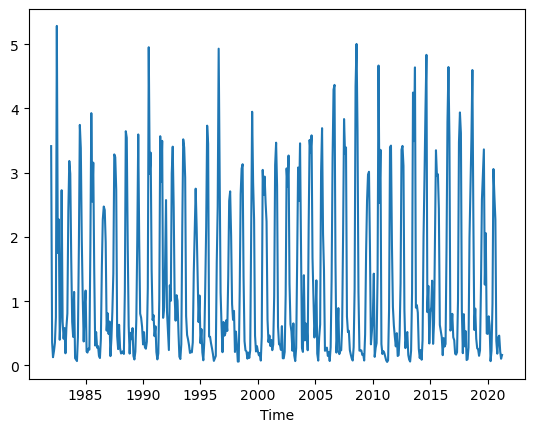

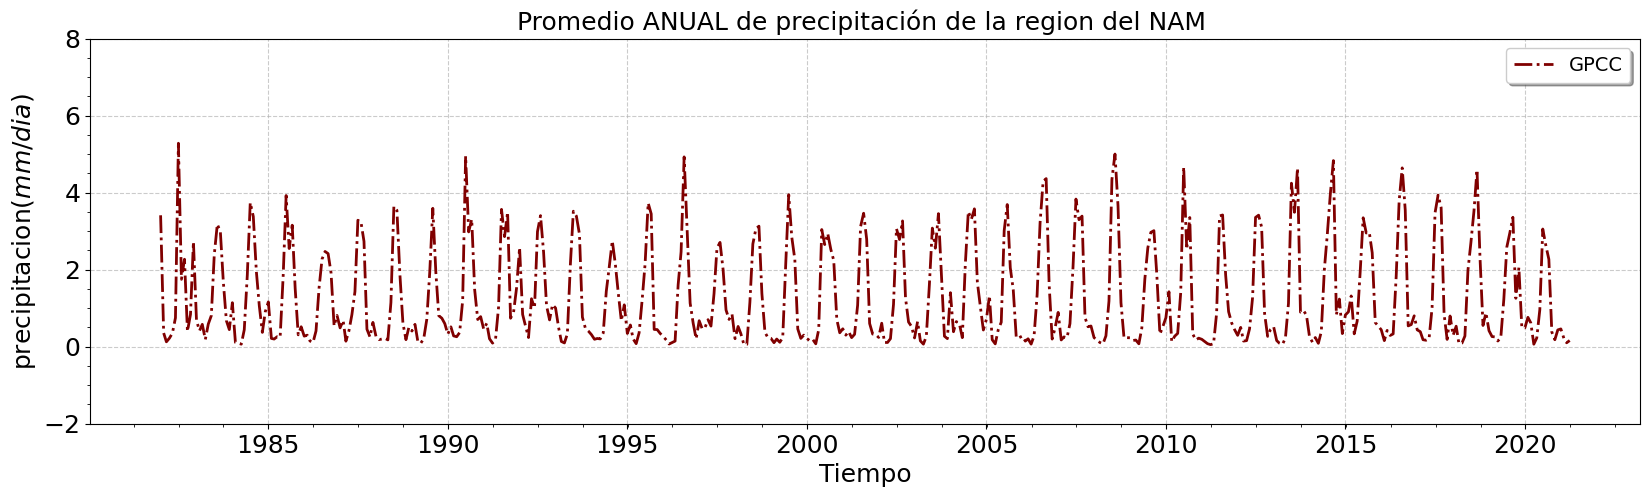

In [92]:
g = ANUAL_mmd.mean(('lat','lon'))  
g.plot()
plt.figure(figsize=(20,5))
plt.plot(ANUAL_mmd.time,g,c='maroon',label='GPCC',linewidth=2,linestyle='-.')
grafico_linea_ts(None,None,'Tiempo','precipitacion($mm /dia$)','Promedio ANUAL de precipitación de la region del NAM ',ymin=-2,ymax=8,legend=True)


In [93]:
POP=ANUAL_mmd['time'].dt.month
pop= ANUAL_mmd.where((POP>=6) & (POP <= 8), drop=True)

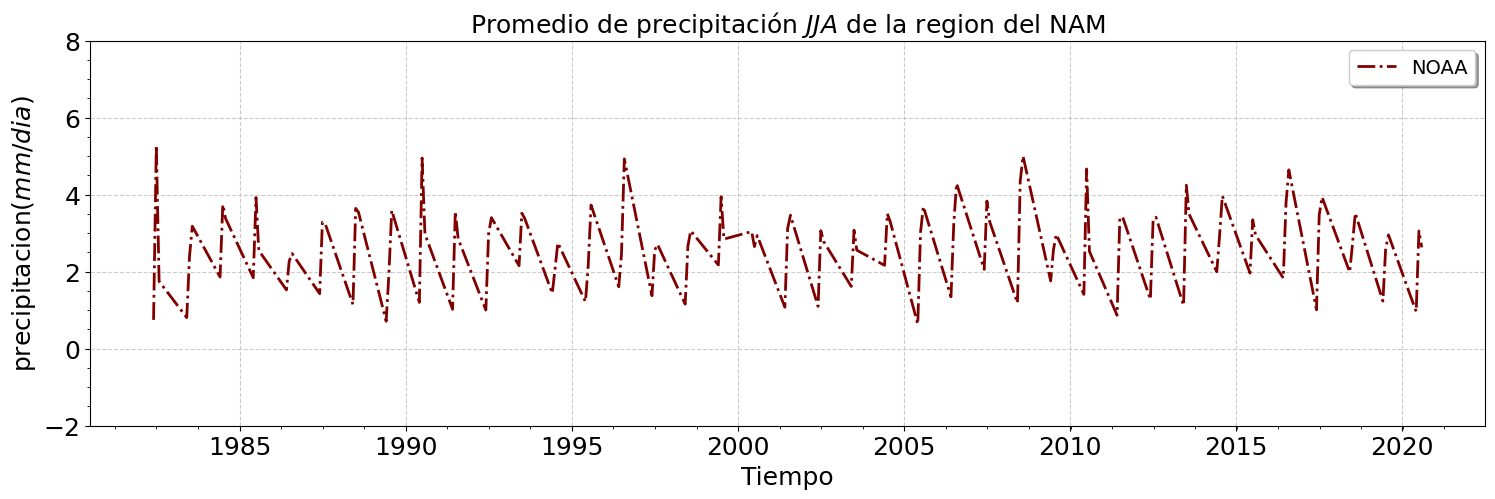

In [94]:
pop_pro= pop.mean(("lat", "lon"), skipna= True)
#pop_pro.plot()
plt.figure(figsize=(18,5))
plt.plot(pop.time,pop_pro,c='maroon',label='NOAA',linewidth=2,linestyle='-.')
grafico_linea_ts(None,None,'Tiempo','precipitacion($mm /dia$)','Promedio de precipitación $JJA$ de la region del NAM',ymin=-2,ymax=8,legend=True)

In [95]:
AÑOCMIP5= Pro.where((per1 >= 1850) & (per1 <= 2000), drop=True)
AÑOCMIP5 = AÑOCMIP5.assign_coords(lon=((AÑOCMIP5.lon + 180) % 360) - 180).sortby('lon')

if AÑOCMIP5.lat[0] > AÑOCMIP5.lat[-1]:
    AÑOCMIP5=AÑOCMIP5.sortby('lat')
AÑOCMIP5_1= AÑOCMIP5.sel(lon=slice(-112, -102), lat=slice(18, 33))
# Si AÑOCMIP5_1 es un DataArray llamado 'pr' en kg m-2 s-1:
CMIP_anual = AÑOCMIP5_1 * 86400.0
CMIP_anual = CMIP_anual.assign_attrs({
    **AÑOCMIP5_1.attrs,
    "units": "mm day-1",
    "long_name": AÑOCMIP5_1.attrs.get("long_name", "Precipitation") + " (daily rate)"
})

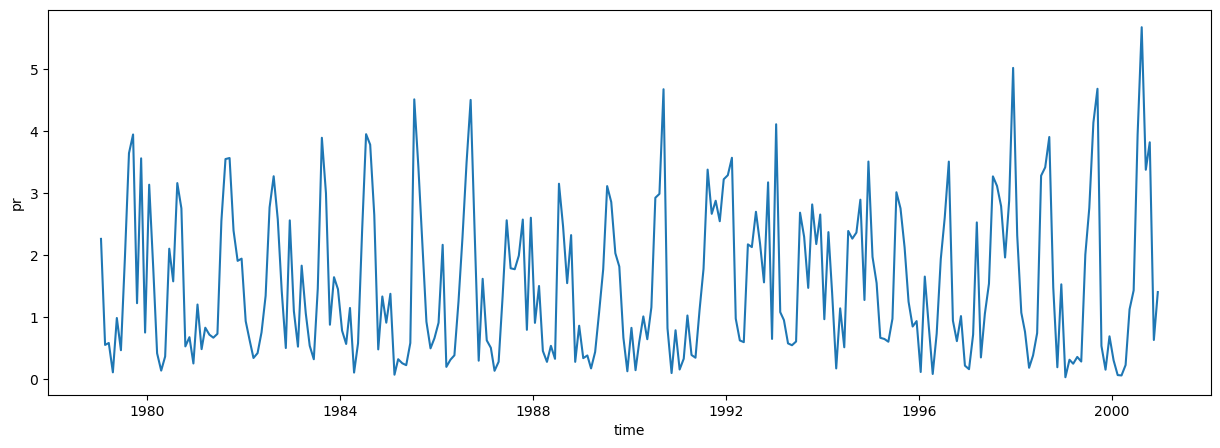

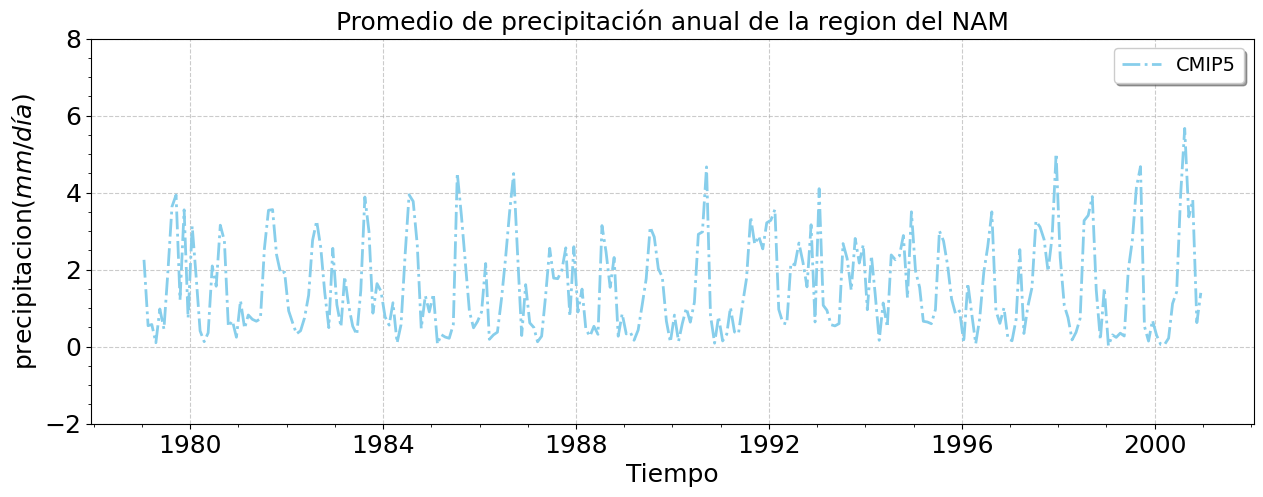

In [96]:
## Serie de tiempo para los datos del CMIP5
plt.figure(figsize=(15,5))
global1_pos = CMIP_anual.mean(('lat','lon'))  
global1_pos.plot()
plt.figure(figsize=(15,5))
plt.plot(CMIP_anual.time,global1_pos,c='skyblue',label='CMIP5',linewidth=2,linestyle='-.')
grafico_linea_ts(None,None,'Tiempo','precipitacion($mm /día$)','Promedio de precipitación anual de la region del NAM',ymin=-2,ymax=8,legend=True)

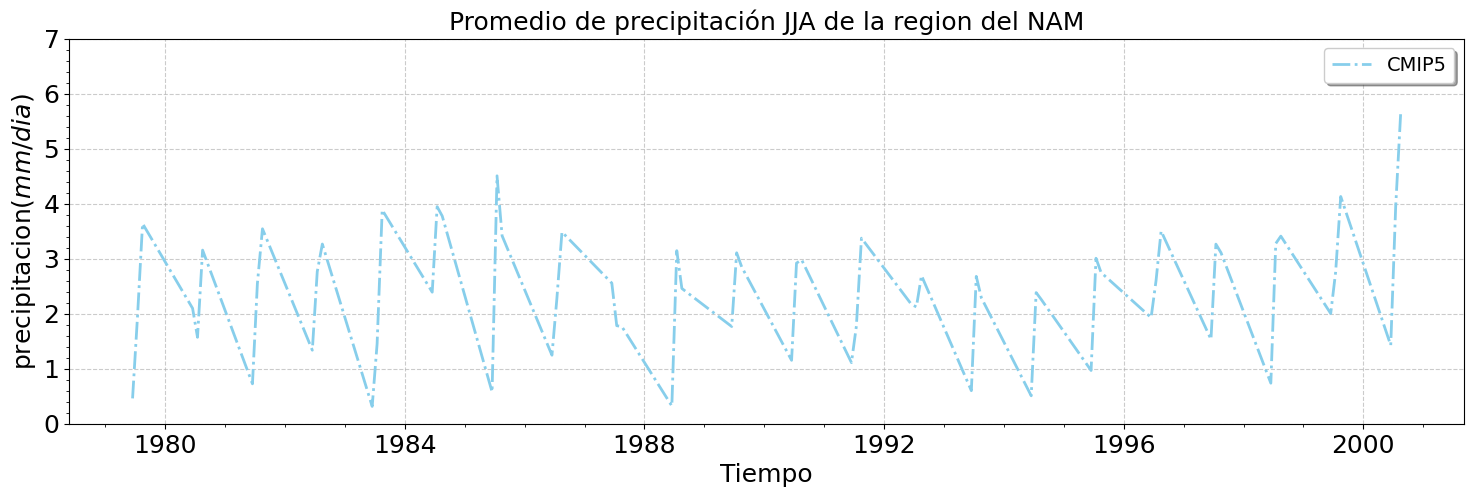

In [97]:
jas=CMIP_anual['time'].dt.month
JJAS= CMIP_anual.where((jas>=6) & (jas <= 8), drop=True)
JJAS_pro= JJAS.mean(("lat", "lon"), skipna= True)
plt.figure(figsize=(18,5))
plt.plot(JJAS.time,JJAS_pro,c='skyblue',label='CMIP5',linewidth=2,linestyle='-.')
grafico_linea_ts(None,None,'Tiempo','precipitacion($mm /dia$)','Promedio de precipitación JJA de la region del NAM',ymin= 0,ymax=7,legend=True)
##plt.savefig('Datos filtrados/Serie de tiempo CMIP5.png')

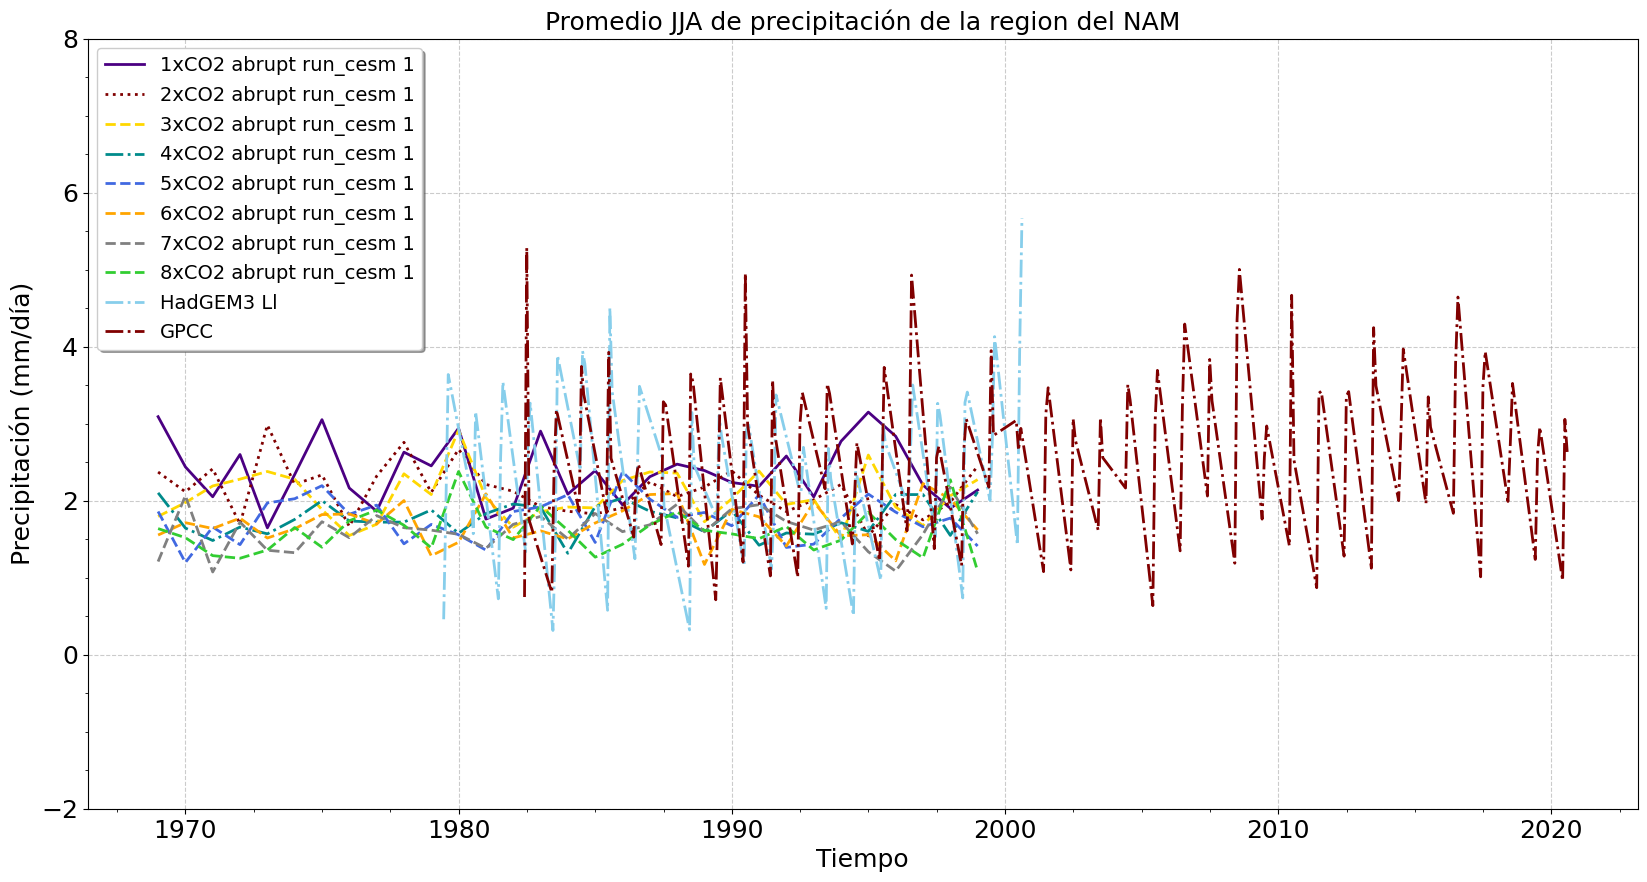

In [98]:
plt.figure(figsize=(20,10))

plt.plot(precip1_jja.year,pre1_jja,c='indigo',label='1xCO2 abrupt run_cesm 1',linewidth=2,linestyle='solid')

plt.plot(precip2_jja.year,pre2_jja,c='maroon',label='2xCO2 abrupt run_cesm 1',linewidth=2,linestyle='dotted')

plt.plot(precip3_jja.year,pre3_jja,c='gold',label='3xCO2 abrupt run_cesm 1',linewidth=2,linestyle='dashed')

plt.plot(precip4_jja.year,pre4_jja,c='darkcyan',label='4xCO2 abrupt run_cesm 1',linewidth=2,linestyle='dashdot')

plt.plot(precip5_jja.year,pre5_jja,c='royalblue',label='5xCO2 abrupt run_cesm 1',linewidth=2,linestyle='dashed')

plt.plot(precip6_jja.year,pre6_jja,c='orange',label='6xCO2 abrupt run_cesm 1',linewidth=2,linestyle='dashed')

plt.plot(precip7_jja.year,pre7_jja,c='grey',label='7xCO2 abrupt run_cesm 1',linewidth=2,linestyle='dashed')

plt.plot(precip8_jja.year,pre8_jja,c='limegreen',label='8xCO2 abrupt run_cesm 1',linewidth=2,linestyle='dashed')

plt.plot(JJAS.time,JJAS_pro,c='skyblue',label='HadGEM3 Ll',linewidth=2,linestyle='-.')

plt.plot(pop.time,pop_pro,c='maroon',label='GPCC',linewidth=2,linestyle='-.')



grafico_linea_ts(None, None,xlab='Tiempo',ylab='Precipitación (mm/día)',title='Promedio JJA de precipitación de la region del NAM',ymin=-2, ymax=8,legend=True)

plt.show()

In [99]:
gpcc_suave = pop_pro.rolling(time=10).mean()
had_suave  = JJAS_pro.rolling(time=10).mean()


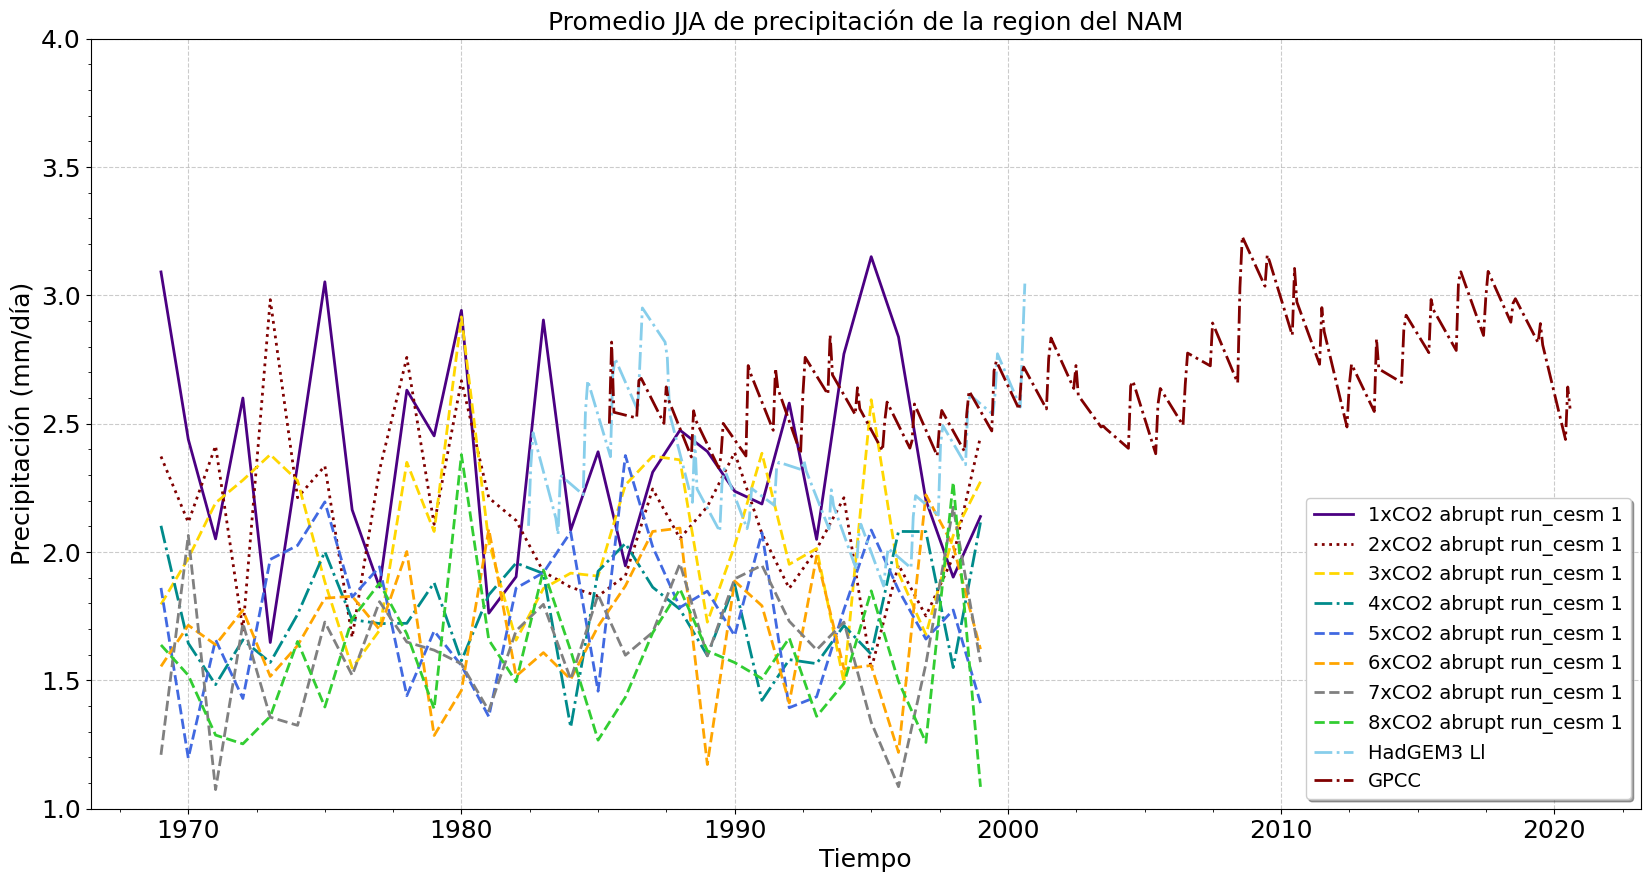

In [100]:
plt.figure(figsize=(20,10))

plt.plot(precip1_jja.year,pre1_jja,c='indigo',label='1xCO2 ',linewidth=2,linestyle='solid')

plt.plot(precip2_jja.year,pre2_jja,c='maroon',label='2xCO2 ',linewidth=2,linestyle='dotted')

plt.plot(precip3_jja.year,pre3_jja,c='gold',label='3xCO2 ',linewidth=2,linestyle='dashed')

plt.plot(precip4_jja.year,pre4_jja,c='darkcyan',label='4xCO2 ',linewidth=2,linestyle='dashdot')

plt.plot(precip5_jja.year,pre5_jja,c='royalblue',label='5xCO2 ',linewidth=2,linestyle='dashed')

plt.plot(precip6_jja.year,pre6_jja,c='orange',label='6xCO2 ',linewidth=2,linestyle='dashed')

plt.plot(precip7_jja.year,pre7_jja,c='grey',label='7xCO2 ',linewidth=2,linestyle='dashed')

plt.plot(precip8_jja.year,pre8_jja,c='limegreen',label='8xCO2',linewidth=2,linestyle='dashed')

plt.plot(JJAS.time,had_suave,c='skyblue',label='HadGEM3 Ll',linewidth=2,linestyle='-.')

plt.plot(pop.time,gpcc_suave,c='maroon',label='GPCC',linewidth=2,linestyle='-.')



grafico_linea_ts(None, None,xlab='Tiempo',ylab='Precipitación (mm/día)',title='Promedio JJA de precipitación de la region del NAM',ymin=1, ymax=4,legend=True)

plt.show()

In [101]:
pre1_suave = pre1_jja.rolling(year=10, center=True).mean()
pre2_suave = pre2_jja.rolling(year=10, center=True).mean()
pre3_suave = pre3_jja.rolling(year=10, center=True).mean()
pre4_suave = pre4_jja.rolling(year=10, center=True).mean()
pre5_suave = pre5_jja.rolling(year=10, center=True).mean()
pre6_suave = pre6_jja.rolling(year=10, center=True).mean()
pre7_suave = pre7_jja.rolling(year=10, center=True).mean()
pre8_suave = pre8_jja.rolling(year=10, center=True).mean()

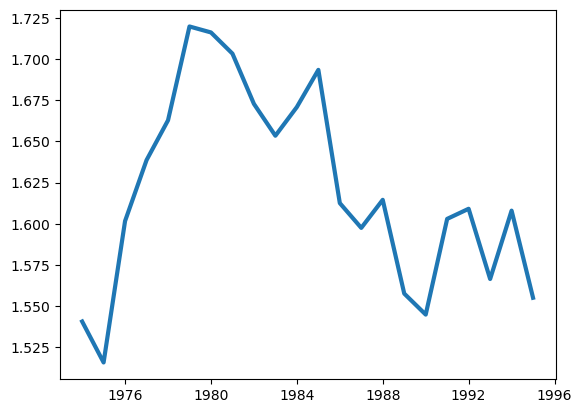

In [102]:
plt.plot(precip8_jja.year, pre8_suave, label="1xCO2 suavizado", linewidth=3)


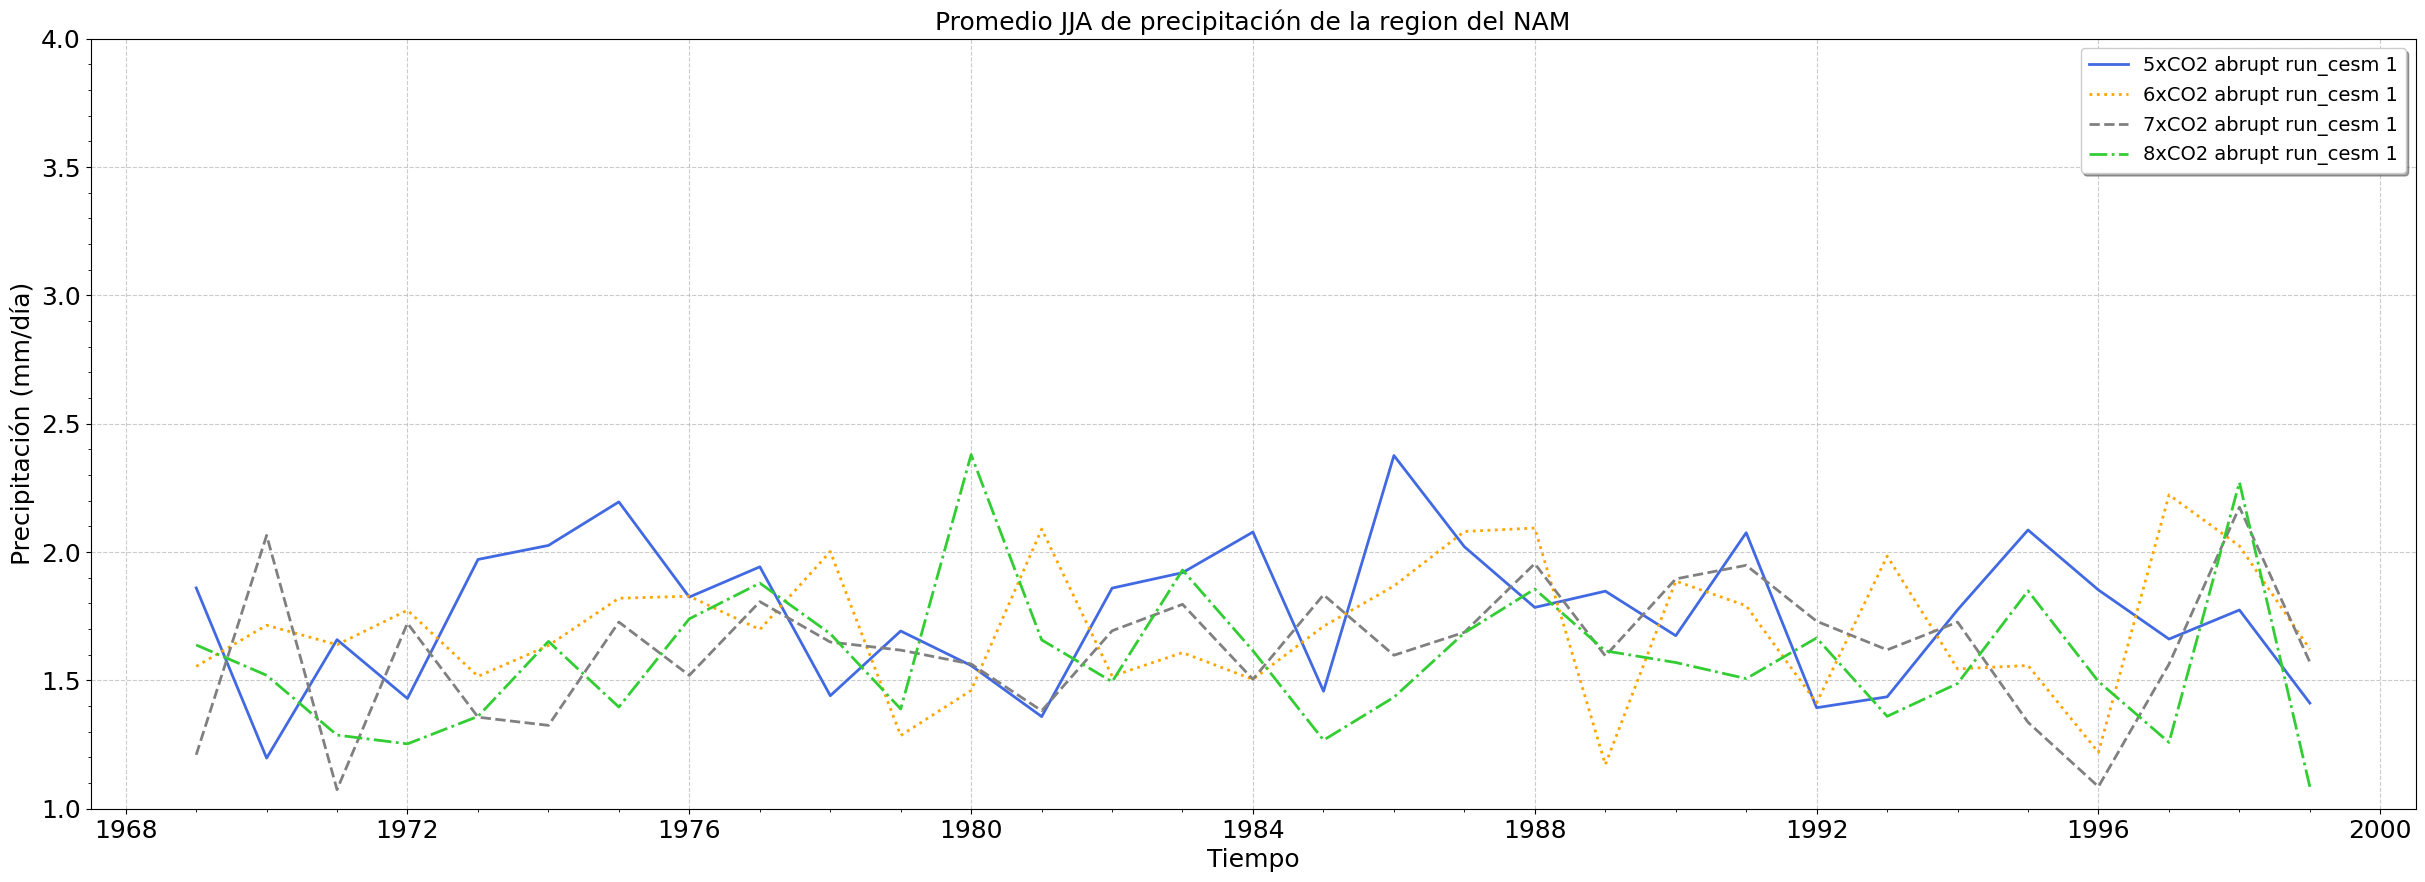

In [103]:
plt.figure(figsize=(30,10))

#plt.plot(precip1_jja.year,pre1_jja,c='indigo',label='1xCO2 abrupt run_cesm 1',linewidth=2,linestyle='dashed')

#plt.plot(precip2_jja.year,pre2_jja,c='maroon',label='2xCO2 abrupt run_cesm 1',linewidth=2,linestyle='dashed')

#plt.plot(precip3_jja.year,pre3_jja,c='gold',label='3xCO2 abrupt run_cesm 1',linewidth=2,linestyle='dashed')

#plt.plot(precip4_jja.year,pre4_jja,c='darkcyan',label='4xCO2 abrupt run_cesm 1',linewidth=2,linestyle='dashed')

plt.plot(precip5_jja.year,pre5_jja,c='royalblue',label='5xCO2 abrupt run_cesm 1',linewidth=2,linestyle='solid')

plt.plot(precip6_jja.year,pre6_jja,c='orange',label='6xCO2 abrupt run_cesm 1',linewidth=2,linestyle='dotted')

plt.plot(precip7_jja.year,pre7_jja,c='grey',label='7xCO2 abrupt run_cesm 1',linewidth=2,linestyle='dashed')

plt.plot(precip8_jja.year,pre8_jja,c='limegreen',label='8xCO2 abrupt run_cesm 1',linewidth=2,linestyle='dashdot')

#plt.plot(JJAS.time,JJAS_pro,c='skyblue',label='HadGEM3 Ll',linewidth=2,linestyle='-.')

#plt.plot(pop.time,pop_pro,c='maroon',label='GPCC',linewidth=2,linestyle='-.')



grafico_linea_ts(None, None,xlab='Tiempo',ylab='Precipitación (mm/día)',title='Promedio JJA de precipitación de la region del NAM',ymin=1, ymax=4,legend=True)

plt.show()

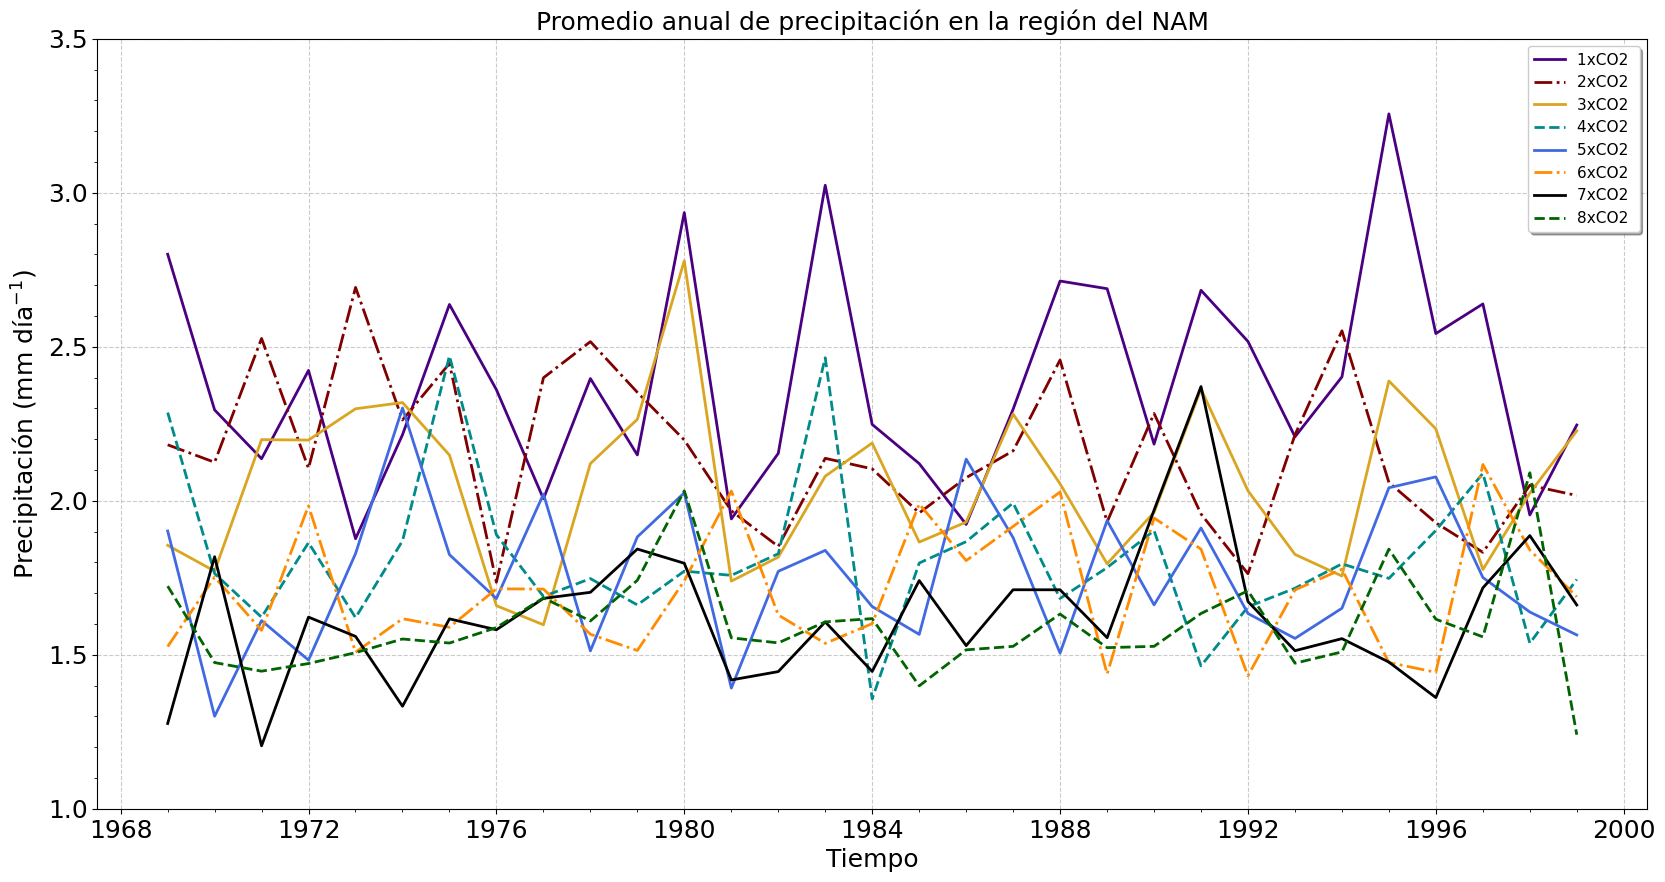

In [125]:
plt.figure(figsize=(20,10))

plt.plot(precip1.year,pre1,c='indigo',label='1xCO2 ',linewidth=2,linestyle='solid')

plt.plot(precip2.year,pre2,c='maroon',label='2xCO2 ',linewidth=2,linestyle='dashdot')

plt.plot(precip4.year,pre3,c='goldenrod',label='3xCO2 ',linewidth=2,linestyle='solid')

plt.plot(precip4.year,pre4,c='darkcyan',label='4xCO2 ',linewidth=2,linestyle='dashed')

plt.plot(precip5.year,pre5,c='royalblue',label='5xCO2 ',linewidth=2,linestyle='solid')

plt.plot(precip6.year,pre6,c='darkorange',label='6xCO2 ',linewidth=2,linestyle='dashdot')

plt.plot(precip7.year,pre7,c='black',label='7xCO2 ',linewidth=2,linestyle='solid')

plt.plot(precip8.year,pre8,c='darkgreen',label='8xCO2 ',linewidth=2,linestyle='dashed')

#plt.plot(ANUAL_mmd.time, g,color='maroon', label='GPCC',linewidth=2, linestyle='-.')


#plt.plot(CMIP_anual.time, global1_pos,color='skyblue', label='CMIP5',linewidth=2, linestyle='-.')

# Configuración de ejes, título, etc.
grafico_linea_ts(None, None,xlab='Tiempo',ylab='Precipitación (mm día$^{-1}$)',title='Promedio anual de precipitación en la región del NAM',ymin=1, ymax=3.5,legend=True)
plt.savefig('Imagenes/Serie_simulaciones1_8_ANUAL.png', dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
plt.plot(precip1_jja.year,pre1_jja,c='indigo',label='1xCO2 abrupt run',linewidth=2,linestyle='solid')

plt.plot(precip2_jja.year,pre2_jja,c='maroon',label='2xCO2 abrupt run',linewidth=2,linestyle='dashdot')

plt.plot(precip3_jja.year,pre3_jja,c='goldenrod',label='3xCO2 abrupt run',linewidth=2,linestyle='solid')

plt.plot(precip4_jja.year,pre4_jja,c='darkcyan',label='4xCO2 abrupt run',linewidth=2,linestyle='dashed')

plt.plot(precip5_jja.year,pre5_jja,c='royalblue',label='5xCO2 abrupt run',linewidth=2,linestyle='solid')

plt.plot(precip6_jja.year,pre6_jja,c='darkorange',label='6xCO2 abrupt run',linewidth=2,linestyle='dashdot')

plt.plot(precip7_jja.year,pre7_jja,c='black',label='7xCO2 abrupt run',linewidth=2,linestyle='solid')

plt.plot(precip8_jja.year,pre8_jja,c='limegreen',label='8xCO2 abrupt run',linewidth=2,linestyle='dashed')

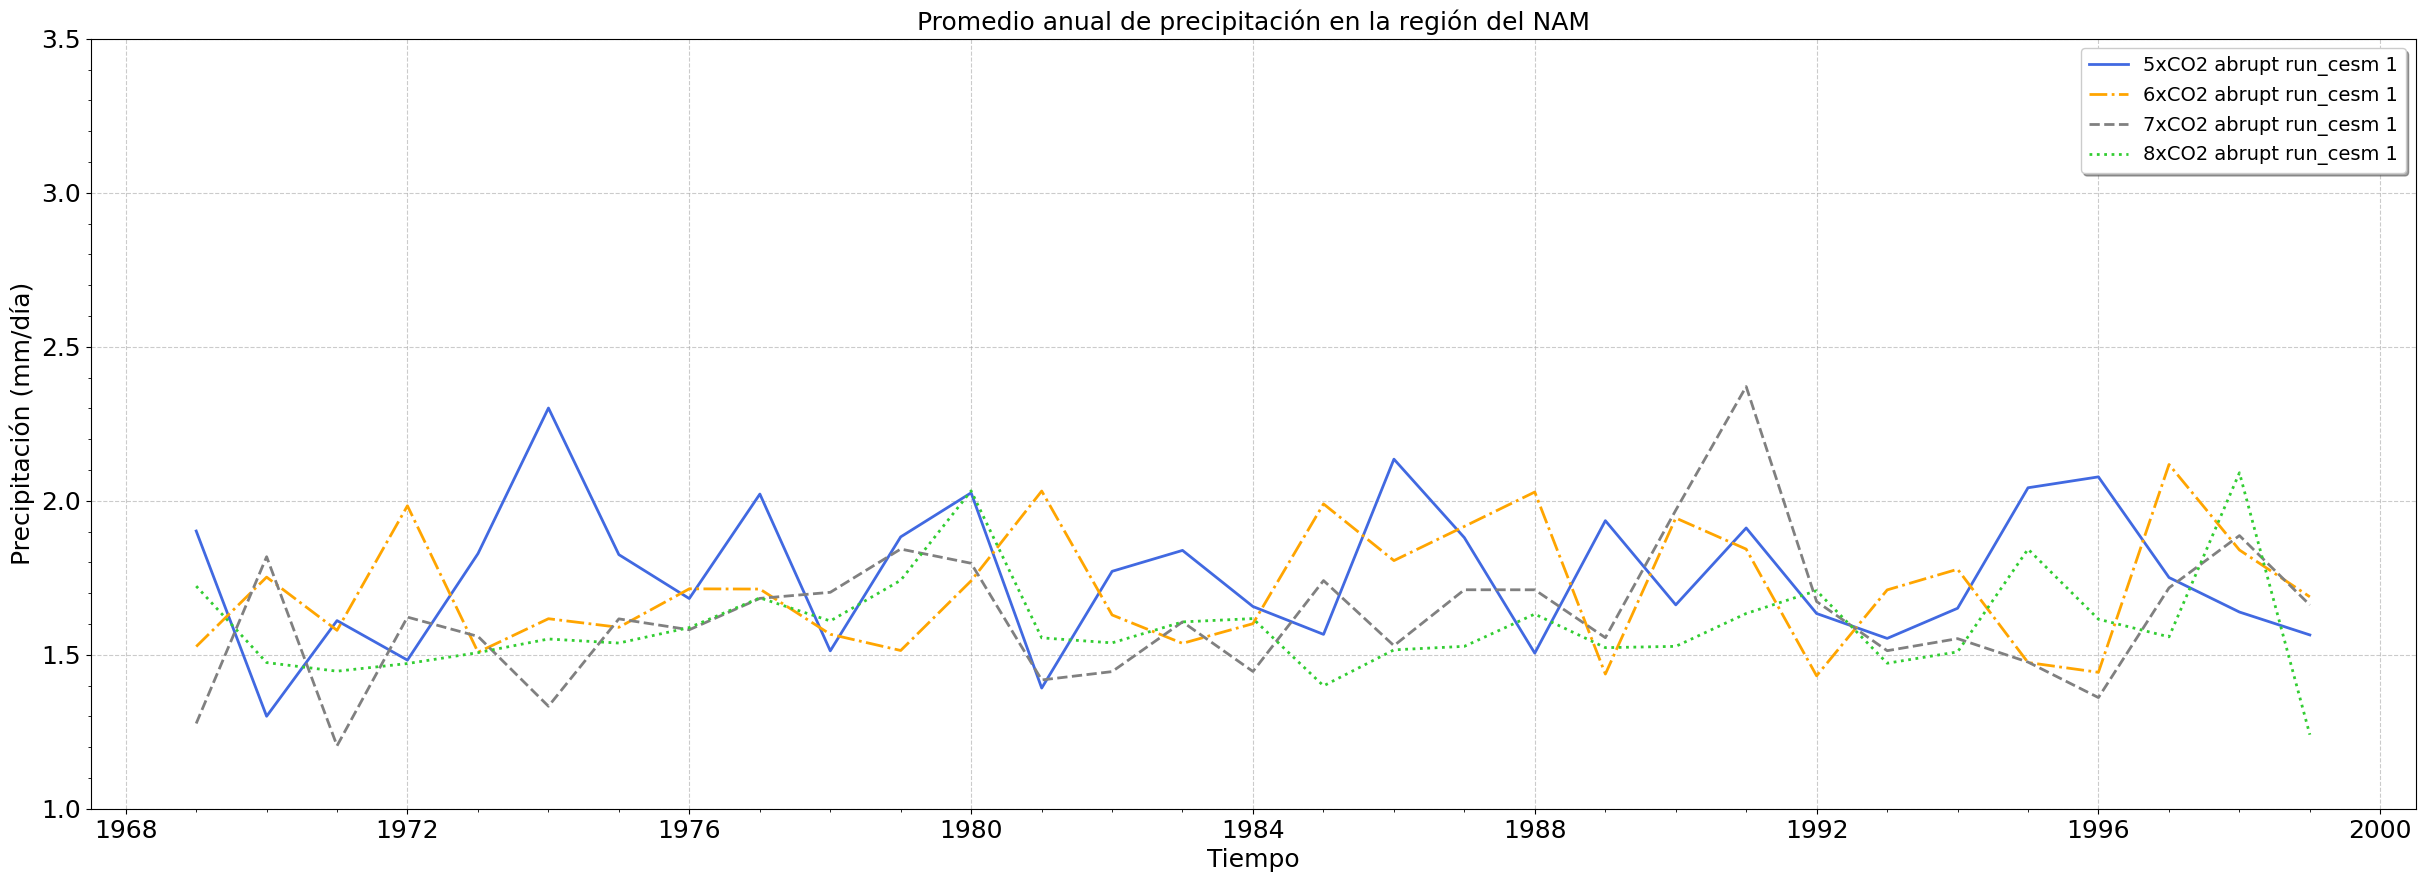

In [105]:
plt.figure(figsize=(30,10))

#plt.plot(precip1.year,pre1,c='indigo',label='1xCO2 abrupt run',linewidth=2,linestyle='solid')

#plt.plot(precip2.year,pre2,c='maroon',label='2xCO2 abrupt run',linewidth=2,linestyle='dashdot')

#plt.plot(precip4.year,pre3,c='gold',label='3xCO2 abrupt run',linewidth=2,linestyle='dashed')

#plt.plot(precip4.year,pre4,c='darkcyan',label='4xCO2 abrupt run',linewidth=2,linestyle='dashed')

plt.plot(precip5.year,pre5,c='royalblue',label='5xCO2 abrupt run_cesm 1',linewidth=2,linestyle='solid')

plt.plot(precip6.year,pre6,c='orange',label='6xCO2 abrupt run_cesm 1',linewidth=2,linestyle='dashdot')

plt.plot(precip7.year,pre7,c='grey',label='7xCO2 abrupt run_cesm 1',linewidth=2,linestyle='dashed')

plt.plot(precip8.year,pre8,c='limegreen',label='8xCO2 abrupt run_cesm 1',linewidth=2,linestyle='dotted')

#plt.plot(ANUAL_mmd.time, g,color='maroon', label='GPCC',linewidth=2, linestyle='-.')


#plt.plot(CMIP_anual.time, global1_pos,color='skyblue', label='CMIP5',linewidth=2, linestyle='-.')

# Configuración de ejes, título, etc.
grafico_linea_ts(None, None,xlab='Tiempo',ylab='Precipitación (mm/día)',title='Promedio anual de precipitación en la región del NAM',ymin=1, ymax=3.5,legend=True)

plt.show()